# CondensateML

## A deep-learning pipeline for condensate phenotyping and image-based clustering from high-content screens

### Features
- ResNet18-based feature extraction (512D embeddings)
- UMAP projection + anchor-based similarity scoring


In [2]:
# ==== Preprocessing & Labeling (Regression: RNF=-1, Neutral=0, ZNF=+1) ====
import os, re, random
import numpy as np
import pandas as pd
from tqdm import tqdm
from skimage.io import imread
from skimage.filters import threshold_otsu
from skimage.measure import label, regionprops
from skimage.transform import resize

import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"   # forces sync; gives accurate stack traces
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"  # optional, helps determinism

# -----------------------------
# CONFIG
# -----------------------------
input_dir = "path_to_training_data"
crop_size, resize_size, half_crop = 100, 224, 50

use_channels = ["GFP"]   # which channels to include

channel_map = {
    "DAPI": "_w1.TIF",
    "GFP": "_w2.TIF",
    "CellMask": "_w3.TIF"
}

# -----------------------------
# Load images (match old)
# -----------------------------
stack, fov_filenames = [], []
fov_filenames = sorted([
    fn.replace(channel_map["DAPI"], "")
    for fn in os.listdir(input_dir)
    if fn.endswith(channel_map["DAPI"])
])

for prefix in tqdm(fov_filenames, desc="Loading FOVs", unit="FOV"):
    img_w1 = imread(os.path.join(input_dir, prefix + channel_map["DAPI"]))
    imgs = {"DAPI": img_w1}

    for ch in use_channels:
        fn = prefix + channel_map[ch]
        if os.path.exists(os.path.join(input_dir, fn)):
            imgs[ch] = imread(os.path.join(input_dir, fn))

    if any(img.shape != img_w1.shape for img in imgs.values()):
        continue

    stack.append(imgs)

print(f"Loaded {len(stack)} FOVs")

# -----------------------------
# Segment nuclei + crop patches (match old)
# -----------------------------
all_patches, output_rows = [], []
for fov_idx, (imgs, fov_name) in tqdm(
    enumerate(zip(stack, fov_filenames)),
    total=len(stack),
    desc="Cropping patches",
    unit="FOV"
):
    dapi = imgs["DAPI"]
    thresh = threshold_otsu(dapi)
    labeled = label(dapi > thresh)
    regions = regionprops(labeled, intensity_image=dapi)

    for region in regions:
        cy, cx = map(int, region.centroid)
        y1, y2, x1, x2 = cy - half_crop, cy + half_crop, cx - half_crop, cx + half_crop
        if y1 < 0 or y2 > dapi.shape[0] or x1 < 0 or x2 > dapi.shape[1]:
            continue

        patch_channels = []
        for ch in use_channels:
            patch = resize(
                imgs[ch][y1:y2, x1:x2],
                (resize_size, resize_size),
                preserve_range=True
            )
            patch_channels.append(patch)

        patch = np.stack(patch_channels, axis=0).astype(np.float32)
        all_patches.append(patch)
        output_rows.append({"name": fov_name})

patches = np.stack(all_patches, axis=0)
print(f"Patch tensor shape: {patches.shape}")

# -----------------------------
# Build metadata + assign labels (match old)
# -----------------------------
meta_df = pd.DataFrame(output_rows)
np.save("resnet18_patches.npy", patches)
meta_df.to_csv("resnet18_patch_metadata.csv", index=False)

# Reload (safe practice) (match old)
patches = np.load("resnet18_patches.npy")
meta_df = pd.read_csv("resnet18_patch_metadata.csv")

# Extract merge key (match old)
meta_df["merge_key"] = meta_df["name"].apply(lambda x: re.search(r"(AC\d+_\w\d+)", x).group(1))

# Plate-to-gene mapping (match old)
raw = pd.read_csv("names.csv", skiprows=2)
raw = raw.iloc[:, [0, 1, 2]]
raw.columns = ["Gene", "Plate", "Well"]
raw.dropna(subset=["Gene", "Plate", "Well"], inplace=True)
raw["merge_key"] = raw["Plate"].astype(str).str.strip() + "_" + raw["Well"].astype(str).str.strip()

meta_df = meta_df.merge(raw[["merge_key", "Gene"]], on="merge_key", how="left")

# Labels: RNF=-1, Neutral=0, ZNF=+1 (match old)
meta_df["label"] = np.nan
meta_df.loc[meta_df["merge_key"].str.endswith("B02"), "label"] = 0
meta_df.loc[meta_df["Gene"] == "ZNF335", "label"] = 1
meta_df.loc[meta_df["Gene"] == "RNF26", "label"] = -1

# Keep labeled rows only (match old)
valid_idx = meta_df.index[~meta_df["label"].isna()]
patches = patches[valid_idx]
meta_df = meta_df.loc[valid_idx].reset_index(drop=True)

# Clean (match old)
meta_df["Gene"] = meta_df["Gene"].replace(["", " ", "nan", "NaN"], np.nan).fillna("NT")

print("Positive genes in training:", meta_df[meta_df.label == 1].Gene.unique())
print("Negative genes in training:", meta_df[meta_df.label == -1].Gene.unique())
print("Neutral wells in training:", meta_df[meta_df.label == 0].merge_key.unique())



Loading FOVs: 100%|███████████████████████████████████████████████████████████████████| 36/36 [00:06<00:00,  5.58FOV/s]


Loaded 36 FOVs


Cropping patches: 100%|███████████████████████████████████████████████████████████████| 36/36 [00:08<00:00,  4.11FOV/s]


Patch tensor shape: (4523, 1, 224, 224)
Positive genes in training: ['ZNF335']
Negative genes in training: ['RNF26']
Neutral wells in training: ['AC0821_B02' 'AC1004_B02']


In [3]:
# ============================================================
# Training + IG saliency snapshots
# ============================================================
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torchvision.models import resnet18
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_absolute_error, roc_auc_score
from scipy.stats import pearsonr
from sklearn.utils import resample

import matplotlib.pyplot as plt

# -----------------------------
# Reproducibility
# -----------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# -----------------------------
# Model 
# -----------------------------
class ResNetRegression(nn.Module):
    def __init__(self, hidden_dim=64, freeze_until_layer=6):
        super().__init__()
        base = resnet18(weights="IMAGENET1K_V1")

        # Freeze early layers (match old)
        child_counter = 0
        for child in base.children():
            child_counter += 1
            if child_counter < freeze_until_layer:
                for param in child.parameters():
                    param.requires_grad = False

        num_ftrs = base.fc.in_features
        base.fc = nn.Identity()
        self.base = base

        self.fc1 = nn.Linear(num_ftrs, hidden_dim)
        self.relu = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout(0.5)  # match old
        self.fc2 = nn.Linear(hidden_dim, 1)

        nn.init.kaiming_normal_(self.fc1.weight, nonlinearity="relu")
        nn.init.constant_(self.fc1.bias, 0)
        nn.init.kaiming_normal_(self.fc2.weight, nonlinearity="linear")
        nn.init.constant_(self.fc2.bias, 0)

    def forward(self, x, return_embed=False):
        # match old: pad to 3 channels if needed
        if x.shape[1] < 3:
            pad = torch.zeros(
                (x.shape[0], 3 - x.shape[1], x.shape[2], x.shape[3]),
                device=x.device, dtype=x.dtype
            )
            x = torch.cat([x, pad], dim=1)

        feats = self.base(x)
        if return_embed:
            return feats
        x = self.fc1(feats)
        x = self.relu(x)
        x = self.dropout(x)
        return self.fc2(x)

model = ResNetRegression(hidden_dim=64, freeze_until_layer=6).to(device)

# -----------------------------
# Dataset prep 
# -----------------------------
labels = meta_df["label"].values  # already -1,0,1

# lobal z-score norm 
X = torch.tensor((patches - patches.mean()) / patches.std(), dtype=torch.float32)

# repeat channels to (N,3,H,W)
X = X.repeat(1, 3, 1, 1)

# Separate classes  
idx_rnf = np.where(labels == -1)[0]
idx_neu = np.where(labels == 0)[0]
idx_znf = np.where(labels == 1)[0]
print("Before undersampling:", len(idx_rnf), len(idx_neu), len(idx_znf))

# Undersample Neutral (0)  
min_size = min(len(idx_rnf), len(idx_znf))
idx_neu_down = resample(idx_neu, replace=False, n_samples=min_size, random_state=SEED)

# Combine balanced 
balanced_idx = np.hstack([idx_rnf, idx_neu_down, idx_znf])
np.random.shuffle(balanced_idx)  # match old

X_bal = X[balanced_idx]
y_bal = torch.tensor(labels[balanced_idx], dtype=torch.float32)

print(
    "After undersampling:",
    (y_bal == -1).sum().item(),
    (y_bal == 0).sum().item(),
    (y_bal == 1).sum().item()
)

# Train/val split  
train_idx, val_idx = train_test_split(
    np.arange(len(y_bal)),
    test_size=0.2,
    stratify=y_bal.numpy(),
    random_state=SEED
)

train_ds = TensorDataset(X_bal[train_idx], y_bal[train_idx])
val_ds   = TensorDataset(X_bal[val_idx],   y_bal[val_idx])

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False, num_workers=0, pin_memory=True)

# -----------------------------
# Optimizer, Loss, Scheduler 
# -----------------------------
criterion = nn.SmoothL1Loss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=5e-2)  # match old
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-6)  # match old


# ============================================================
# Integrated Gradients saliency 
# ============================================================
def _minmax_np(a: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    a = a - a.min()
    return a / (a.max() + eps)

def integrated_gradients(model, x, baseline=None, steps=24):
    """
    IG for regression.
    x: (1,3,H,W)
    returns attr: (1,3,H,W)
    """
    model.eval()
    if baseline is None:
        baseline = torch.zeros_like(x)

    # interpolate
    alphas = torch.linspace(0, 1, steps, device=x.device).view(steps, 1, 1, 1)
    x_scaled = baseline + alphas * (x - baseline)  # (steps,3,H,W)
    x_scaled.requires_grad_(True)

    out = model(x_scaled)  # (steps,1)
    target = out.sum()

    model.zero_grad(set_to_none=True)
    target.backward()

    grads = x_scaled.grad  # (steps,3,H,W)
    avg_grads = grads.mean(dim=0, keepdim=True)  # (1,3,H,W)
    attr = (x - baseline) * avg_grads
    return attr.detach()

@torch.no_grad()
def predict_scalar(model, x1):
    return float(model(x1).detach().cpu().numpy().ravel()[0])

def attr_to_heatmap(attr_13hw: torch.Tensor) -> np.ndarray:
    a = attr_13hw.abs().sum(dim=1)[0]  # (H,W)
    a = a.detach().cpu().float().numpy()
    return _minmax_np(a)

def normalize_for_display(x_13hw: torch.Tensor) -> np.ndarray:
    # show channel 0; re-normalize for plotting only
    x = x_13hw[0, 0].detach().cpu().float()
    x = (x - x.min()) / (x.max() - x.min() + 1e-8)
    return x.numpy()

def label_name(v):
    if v == -1: return "RNF26 (-1)"
    if v == 0:  return "Neutral (0)"
    if v == 1:  return "ZNF335 (+1)"
    return str(v)

def save_saliency_panel(save_path, items, title=None, rows=8, cols=3):
    fig, axes = plt.subplots(rows, cols, figsize=(3.8 * cols, 3.4 * rows))
    axes = np.array(axes).reshape(-1)

    for ax_i, ax in enumerate(axes):
        if ax_i < len(items):
            it = items[ax_i]
            ax.imshow(it["img"], cmap="gray")
            ax.imshow(it["heat"], cmap="jet", alpha=0.45)
            ax.set_title(
                f"{it['gene']}\n{it['label_name']} | true={it['y_true']:.0f} pred={it['y_pred']:.2f}",
                fontsize=9
            )
            ax.axis("off")
        else:
            ax.axis("off")

    if title:
        fig.suptitle(title, fontsize=14)

    fig.tight_layout()
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.close(fig)
 

# Saliency output dirs 
SAL_DIR = "saliency_maps"
os.makedirs(SAL_DIR, exist_ok=True)

# -----------------------------
# Monitor examples from VAL (8 genes x 3 images)
# -----------------------------
IG_STEPS = 24
SAL_EVERY = 5

N_GENES_TO_PLOT = 3        # rows
PLOT_PER_GENE = 10          # cols

# Build val tensors
X_val_all = X_bal[val_idx].clone()
y_val_all = y_bal[val_idx].clone()

# IMPORTANT: map back to original rows in meta_df
val_orig_idx = balanced_idx[val_idx]  # indices into the original patches/meta_df

# Gene labels for val samples
val_genes = meta_df.iloc[val_orig_idx]["Gene"].astype(str).values

rng = np.random.default_rng(SEED)

# Pick 8 genes that actually exist in val
unique_genes = np.array(sorted(set(val_genes)))
if len(unique_genes) == 0:
    monitor_idx = np.array([], dtype=int)
else:
    chosen_genes = rng.choice(unique_genes, size=min(N_GENES_TO_PLOT, len(unique_genes)), replace=False)

    # For each chosen gene, pick up to 3 val samples
    monitor_idx = []
    monitor_gene_row = []  # same length as monitor_idx, used for labeling
    for g in chosen_genes:
        gi = np.where(val_genes == g)[0]
        if len(gi) == 0:
            continue

        # pick exactly PLOT_PER_GENE per gene; use replacement if not enough cells
        replace = len(gi) < PLOT_PER_GENE
        pick = rng.choice(gi, size=PLOT_PER_GENE, replace=replace)
        
        # Keep row grouped by gene
        for p in pick.tolist():
            monitor_idx.append(p)
            monitor_gene_row.append(g)

    monitor_idx = np.array(monitor_idx, dtype=int)

monitor_X = X_val_all[monitor_idx].clone() if len(monitor_idx) else torch.empty((0, *X_val_all.shape[1:]))
monitor_y = y_val_all[monitor_idx].clone() if len(monitor_idx) else torch.empty((0,), dtype=y_val_all.dtype)

print(f"Monitor set: {len(monitor_X)} images across up to {N_GENES_TO_PLOT} genes (rows) x {PLOT_PER_GENE} reps (cols)")


def save_monitor_saliency(epoch_tag: str):
    if len(monitor_X) == 0:
        return

    model.eval()
    items = []

    #  Clear grads before/after to avoid any weird leakage.
    model.zero_grad(set_to_none=True)

    for j in range(len(monitor_X)):
        x1 = monitor_X[j:j+1].to(device)  # (1,3,H,W)
        baseline = torch.zeros_like(x1)

        attr = integrated_gradients(model, x1, baseline=baseline, steps=IG_STEPS)
        heat = attr_to_heatmap(attr)
        pred = predict_scalar(model, x1)

        img = normalize_for_display(x1)
        y_true = float(monitor_y[j].detach().cpu().numpy())


        gene = str(monitor_gene_row[j])  

        items.append({
            "img": img,
            "heat": heat,
            "y_true": y_true,
            "y_pred": pred,
            "label_name": label_name(int(y_true)),
            "gene": gene,               
        })


    out_path = os.path.join(SAL_DIR, f"saliency_IG_epoch_{epoch_tag}.png")
    
    N_ROWS_ACTUAL = len(chosen_genes)
    
    save_saliency_panel(
        out_path,
        items,
        title=f"Integrated Gradients (steps={IG_STEPS}) @ epoch {epoch_tag}",
        rows=N_ROWS_ACTUAL,
        cols=PLOT_PER_GENE
    )
    print(f"Saved IG panel: {out_path}")

    model.zero_grad(set_to_none=True)

# Optional: epoch 0 saliency  
save_monitor_saliency(epoch_tag="000")


# -----------------------------
# Training loop  
# -----------------------------
train_history = []

def train_with_early_stopping(max_epochs=100, patience=25):
    best_val_loss, patience_counter = float("inf"), 0

    for epoch in range(max_epochs):
        # --- Train --- (match old)
        model.train()
        train_losses = []
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device).unsqueeze(1)
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())
        train_loss = np.mean(train_losses)

        # --- Validate ---
        model.eval()
        val_preds, val_truth, val_losses = [], [], []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device).unsqueeze(1)
                preds = model(xb)
                loss = criterion(preds, yb)
                val_losses.append(loss.item())
                val_preds.extend(preds.cpu().numpy().ravel())
                val_truth.extend(yb.cpu().numpy().ravel())
        val_loss = np.mean(val_losses)

        # --- Metrics --- 
        val_truth = np.array(val_truth)
        val_preds = np.array(val_preds)
        mae = mean_absolute_error(val_truth, val_preds)
        corr = pearsonr(val_truth, val_preds)[0]
        val_preds_class = np.rint(val_preds).astype(int)
        acc = (val_preds_class == val_truth).mean()

        auc = np.nan
        mask = np.isin(val_truth, [-1, 1])
        if mask.sum() > 0:
            truth_bin = (val_truth[mask] == 1).astype(int)
            scores = (np.clip(val_preds[mask], -1, 1) + 1) / 2
            auc = roc_auc_score(truth_bin, scores)

        print(
            f"Epoch {epoch+1:03d}/{max_epochs} | TrainLoss={train_loss:.4f} | "
            f"ValLoss={val_loss:.4f} | MAE={mae:.3f} | Corr={corr:.3f} | "
            f"Acc={acc:.3f} | AUC={auc:.3f}"
        )

        train_history.append({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "val_acc": acc,
            "mae": mae,
            "corr": corr,
            "auc": auc
        })

        # saliency snapshots periodically 
        if (epoch + 1) % SAL_EVERY == 0:
            save_monitor_saliency(epoch_tag=f"{epoch+1:03d}")

        # Early stopping 
        if val_loss < best_val_loss:
            best_val_loss, patience_counter = val_loss, 0
            torch.save(model.state_dict(), "similarity_model_best.pt")
            print(f"Saved best model (ValLoss={val_loss:.4f})")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping")
                break

        scheduler.step()

train_with_early_stopping(max_epochs=21, patience=25)

Device: cuda
Before undersampling: 728 2938 857
After undersampling: 728 728 857
Monitor set: 30 images across up to 3 genes (rows) x 10 reps (cols)
Saved IG panel: saliency_maps\saliency_IG_epoch_000.png
Epoch 001/21 | TrainLoss=0.5313 | ValLoss=0.2953 | MAE=0.652 | Corr=0.323 | Acc=0.423 | AUC=0.707
Saved best model (ValLoss=0.2953)
Epoch 002/21 | TrainLoss=0.2980 | ValLoss=0.2238 | MAE=0.550 | Corr=0.554 | Acc=0.533 | AUC=0.851
Saved best model (ValLoss=0.2238)
Epoch 003/21 | TrainLoss=0.2017 | ValLoss=0.2125 | MAE=0.533 | Corr=0.634 | Acc=0.516 | AUC=0.898
Saved best model (ValLoss=0.2125)
Epoch 004/21 | TrainLoss=0.1560 | ValLoss=0.2212 | MAE=0.512 | Corr=0.568 | Acc=0.624 | AUC=0.844
Epoch 005/21 | TrainLoss=0.1345 | ValLoss=0.1907 | MAE=0.482 | Corr=0.634 | Acc=0.635 | AUC=0.887
Saved IG panel: saliency_maps\saliency_IG_epoch_005.png
Saved best model (ValLoss=0.1907)
Epoch 006/21 | TrainLoss=0.1120 | ValLoss=0.1852 | MAE=0.487 | Corr=0.706 | Acc=0.592 | AUC=0.934
Saved best mode

In [4]:
# ============================================================
# RNF vs ZNF saliency analysis (aligned to GOI features + workflow)
# ============================================================

import os
import numpy as np
import pandas as pd
import torch
from scipy.stats import mannwhitneyu
from scipy.ndimage import label as cc_label

# -----------------------------
# Config
# -----------------------------
SEED = 42
MAX_CELLS_PER_CLASS = 250   # cap per class (RNF, ZNF)
IG_STEPS = 24

TOP_FRAC_HEAT   = 0.02      # top 2% saliency pixels = hotspots
TOP_FRAC_PUNCTA = 0.02      # top 2% GFP pixels = puncta

SAL_OUTDIR = "saliency_RNF_vs_ZNF"
os.makedirs(SAL_OUTDIR, exist_ok=True)

rng = np.random.default_rng(SEED)

# -----------------------------
# Assumes already defined in your session:
#   - model, device
#   - integrated_gradients(model, x, baseline, steps)
#   - attr_to_heatmap(attr) -> (H,W) float in [0,1]
#   - X_val_all, y_val_all
 
# ============================================================
# Helpers: feature definitions (same set as GOI part)
# ============================================================
def heat_entropy(h, bins=64):
    hist, _ = np.histogram(h.ravel(), bins=bins, range=(0, 1), density=True)
    p = hist + 1e-12
    p /= p.sum()
    return float(-(p * np.log(p)).sum())

def heat_gini(h):
    x = np.sort(h.ravel())
    n = len(x)
    if x.sum() == 0:
        return 0.0
    return float((2 * np.arange(1, n+1) - n - 1) @ x / (n * x.sum()))

def heat_effective_npix(h):
    p = h.ravel()
    p = p / (p.sum() + 1e-12)
    return float(1.0 / np.sum(p**2))

def heat_hotspot_components(h, top_frac=TOP_FRAC_HEAT):
    thr = np.quantile(h, 1.0 - top_frac)
    mask = (h >= thr).astype(np.uint8)
    lab, n = cc_label(mask)
    if n == 0:
        return 0.0, 0.0
    sizes = np.bincount(lab.ravel())[1:]
    return float(n), float(sizes.mean())

def puncta_overlap_score(img01, heat01, puncta_top_frac=TOP_FRAC_PUNCTA):
    thr = np.quantile(img01, 1.0 - puncta_top_frac)
    pmask = img01 >= thr
    if pmask.sum() == 0 or (~pmask).sum() == 0:
        return np.nan
    return float(heat01[pmask].mean() - heat01[~pmask].mean())

# ============================================================
# Resolve RAW patch source for puncta overlap
# ============================================================
# We need raw GFP patch in [0,1] for each val sample.
# Preferred: you already have patches_raw01 shaped (N,1,H,W) in 0..1.
# If you only have `patches` (raw uint16/float), we normalize per-patch below.

def _get_val_raw01_arrays():
    """
    Returns:
      - raw01_val: np.ndarray (N_val,1,H,W) in 0..1
      - val_labels: np.ndarray (N_val,)
    """
    # Case 1: user already has X_val_raw01 in workspace
    if "X_val_raw01" in globals():
        raw01_val = globals()["X_val_raw01"]
        if isinstance(raw01_val, torch.Tensor):
            raw01_val = raw01_val.detach().cpu().numpy()
        return raw01_val, y_val_all.detach().cpu().numpy()

    # Case 2: derive from `patches` + mapping val_orig_idx
    # Requires `patches` and `val_orig_idx` in globals()
    if "patches" in globals() and "val_orig_idx" in globals():
        p = globals()["patches"]
        if isinstance(p, torch.Tensor):
            p = p.detach().cpu().numpy()

        # Expect p shape: (N,1,H,W) or (N,H,W)
        p_sel = p[globals()["val_orig_idx"]]

        # normalize each patch to 0..1 (per-patch)
        if p_sel.ndim == 3:
            p_sel = p_sel[:, None, :, :]
        raw01 = np.empty_like(p_sel, dtype=np.float32)
        for i in range(len(p_sel)):
            a = p_sel[i, 0].astype(np.float32)
            a = (a - a.min()) / (a.max() - a.min() + 1e-8)
            raw01[i, 0] = a
        return raw01, y_val_all.detach().cpu().numpy()

    raise RuntimeError(
        "Need RAW patches for puncta overlap.\n"
        "Provide either `X_val_raw01` (N_val,1,H,W in 0..1) OR "
        "`patches` + `val_orig_idx` mapping back to original patches."
    )

raw01_val, labels_np = _get_val_raw01_arrays()

# ============================================================
# Select RNF (-1) and ZNF (+1) from val
# ============================================================
idx_rnf = np.where(labels_np == -1)[0]
idx_znf = np.where(labels_np ==  1)[0]

if len(idx_rnf) == 0 or len(idx_znf) == 0:
    raise ValueError(f"No RNF or ZNF in val set. RNF={len(idx_rnf)} ZNF={len(idx_znf)}")

# cap per class deterministically
if len(idx_rnf) > MAX_CELLS_PER_CLASS:
    idx_rnf = rng.choice(idx_rnf, size=MAX_CELLS_PER_CLASS, replace=False)
if len(idx_znf) > MAX_CELLS_PER_CLASS:
    idx_znf = rng.choice(idx_znf, size=MAX_CELLS_PER_CLASS, replace=False)

binary_idx = np.concatenate([idx_rnf, idx_znf])
rng.shuffle(binary_idx)

print(f"[Saliency] RNF vs ZNF: RNF={len(idx_rnf)} ZNF={len(idx_znf)} total={len(binary_idx)}")

# ============================================================
# Per-cell saliency stats (aligned to GOI part)
# ============================================================
def compute_cell_stats(val_i: int):
    """
    val_i indexes into X_val_all / y_val_all / raw01_val (VAL-space)
    """
    # model input: use X_val_all (already training-matched zscore + 3ch)
    x1 = X_val_all[val_i:val_i+1].to(device)

    # raw patch for puncta overlap (0..1, 1xHxW)
    img01 = raw01_val[val_i, 0].astype(np.float32)

    # IG
    attr = integrated_gradients(
        model,
        x1,
        baseline=torch.zeros_like(x1),
        steps=IG_STEPS
    )
    heat = attr_to_heatmap(attr)  # (H,W) in [0,1]

    # stats
    ent = heat_entropy(heat)
    n_hot, mean_sz = heat_hotspot_components(heat, top_frac=TOP_FRAC_HEAT)
    gini = heat_gini(heat)
    effn = heat_effective_npix(heat)
    po = puncta_overlap_score(img01, heat, puncta_top_frac=TOP_FRAC_PUNCTA)

    y = int(labels_np[val_i])
    return {
        "val_idx": int(val_i),
        "label": int(y),  # -1 or +1
        "n_hotspots": float(n_hot),
        "hotspot_mean_size": float(mean_sz),
        "heat_gini": float(gini),
        "heat_effective_npix": float(effn),
        "puncta_overlap": np.nan if np.isnan(po) else float(po),
        "entropy": float(ent),
    }

rows = [compute_cell_stats(i) for i in binary_idx]
df_feat = pd.DataFrame(rows)

# ============================================================
# Medians-only summary (RNF vs ZNF) — like GOI medians-only
# ============================================================
features = [
    "n_hotspots",
    "hotspot_mean_size",
    "heat_gini",
    "heat_effective_npix",
    "puncta_overlap",
    "entropy",
]

def _median_skipna(s: pd.Series) -> float:
    return float(s.dropna().median()) if s.dropna().shape[0] else np.nan

summ_rows = []
for lab, name in [(-1, "RNF26"), (1, "ZNF335")]:
    sub = df_feat[df_feat["label"] == lab]
    if len(sub) == 0:
        continue
    summ_rows.append({
        "group": name,
        "label": int(lab),
        "n_reps": int(len(sub)),
        **{f"{f}_median": _median_skipna(sub[f]) for f in features}
    })

df_medians = pd.DataFrame(summ_rows)

# ============================================================
# Mann–Whitney comparisons (per-cell stats)
# ============================================================
df_rnf = df_feat[df_feat["label"] == -1]
df_znf = df_feat[df_feat["label"] ==  1]

mw_rows = []
for f in features:
    a = df_rnf[f].dropna().values
    b = df_znf[f].dropna().values
    if len(a) < 5 or len(b) < 5:
        continue
    mw_rows.append({
        "feature": f,
        "median_RNF": float(np.median(a)),
        "median_ZNF": float(np.median(b)),
        "p_value": float(mannwhitneyu(a, b, alternative="two-sided").pvalue),
    })

df_mw = pd.DataFrame(mw_rows).sort_values("p_value") if len(mw_rows) else pd.DataFrame()

print("\n=== [Saliency] RNF vs ZNF medians-only ===")
print(df_medians.to_string(index=False))

print("\n=== [Saliency] RNF vs ZNF Mann–Whitney (per-cell stats) ===")
if len(df_mw):
    print(df_mw.to_string(index=False))
else:
    print("(not enough samples to run MW)")

# ============================================================
# Export
# ============================================================
raw_csv   = os.path.join(SAL_OUTDIR, "RNF_ZNF_saliency_raw_features.excel")
med_csv   = os.path.join(SAL_OUTDIR, "RNF_ZNF_saliency_medians_only.excel")
mw_csv    = os.path.join(SAL_OUTDIR, "RNF_ZNF_saliency_mannwhitney.excel")

df_feat.to_excel(raw_csv, index=False)
df_medians.to_excel(med_csv, index=False)
if len(df_mw):
    df_mw.to_excel(mw_csv, index=False)

print("\nSaved:")
print(" -", raw_csv)
print(" -", med_csv)
if len(df_mw):
    print(" -", mw_csv)

# ============================================================
# Export
# ============================================================
raw_csv   = os.path.join(SAL_OUTDIR, "RNF_ZNF_saliency_raw_features.xlsx")
med_csv   = os.path.join(SAL_OUTDIR, "RNF_ZNF_saliency_medians_only.xlsx")
mw_csv    = os.path.join(SAL_OUTDIR, "RNF_ZNF_saliency_mannwhitney.xlsx")

df_feat.to_excel(raw_csv, index=False)
df_medians.to_excel(med_csv, index=False)
if len(df_mw):
    df_mw.to_excel(mw_csv, index=False)

print("\nSaved:")
print(" -", raw_csv)
print(" -", med_csv)
if len(df_mw):
    print(" -", mw_csv)


[Saliency] RNF vs ZNF: RNF=146 ZNF=171 total=317

=== [Saliency] RNF vs ZNF medians-only ===
 group  label  n_reps  n_hotspots_median  hotspot_mean_size_median  heat_gini_median  heat_effective_npix_median  puncta_overlap_median  entropy_median
 RNF26     -1     146              159.5                  6.294733          0.540796                 8746.838260               0.053886        0.536420
ZNF335      1     171              122.0                  8.229508          0.587926                 6588.144254               0.063137        0.431307

=== [Saliency] RNF vs ZNF Mann–Whitney (per-cell stats) ===
            feature  median_RNF  median_ZNF  p_value
         n_hotspots  159.500000  122.000000 0.001102
  hotspot_mean_size    6.294733    8.229508 0.001102
heat_effective_npix 8746.838260 6588.144254 0.003467
          heat_gini    0.540796    0.587926 0.008286
            entropy    0.536420    0.431307 0.033072
     puncta_overlap    0.053886    0.063137 0.085999

Saved:
 - saliency


Saved:
 - saliency_GOI\RNF_ZNF_saliency_raw_features.xlsx
 - saliency_GOI\RNF_ZNF_saliency_medians_only.xlsx
 - saliency_GOI\RNF_ZNF_saliency_mannwhitney.xlsx


In [5]:
# ============================================================
# Inference (Regression: RNF=-1, Neutral=0, ZNF=+1)
#     AFTER the full inference finishes (so nothing in the inference path changes),
#     pick REP_PER_GENE representative cells (nearest-to-centroid in embedding space),
#     then compute Integrated Gradients saliency + export stats + save grids.
# ============================================================

import os, re, cv2
import numpy as np, pandas as pd
from tqdm import tqdm
import tifffile as tiff
from skimage.filters import threshold_otsu
from skimage.measure import label, regionprops_table
from collections import defaultdict
from sklearn.metrics.pairwise import cosine_similarity

import torch, torch.nn as nn
from torchvision.models import resnet18

import matplotlib.pyplot as plt
from scipy.ndimage import label as cc_label
from scipy.stats import mannwhitneyu


# -----------------------------
# Config
# -----------------------------
test_dir    = "D:/YCMD/WT_Crispr_Screen/top_hits2/"

output_xlsx = "gene_similarity_predictions_inferenceFullList.xlsx"
names_csv   = "names.csv"
model_path  = "similarity_model_best.pt"

resize_size, half_crop, batch_size = 224, 50, 64
model_channels = ["GFP"]
channel_map = {"DAPI": "_w1.TIF","GFP": "_w2.TIF","CellMask": "_w3.TIF"}

# -----------------------------
# ADDED: GOI saliency config (does NOT affect inference outputs)
# -----------------------------
GENES_OF_INTEREST = {"NCAPD3","NCAPG2","NCAPH2","TOR1A","TOR1B","ZNF335","RNF26"}
N_STATS_PER_GENE = 200
N_SAVE_PER_GENE  = 20
IG_STEPS = 24
SAL_OUTDIR = "saliency_GOI"
os.makedirs(SAL_OUTDIR, exist_ok=True)

# cap per gene for GOI rep selection (kept same value as your inference cap)
MAX_CELLS = 500
rng = np.random.default_rng(42) 


# -----------------------------
# Gene mapping
# -----------------------------
raw = pd.read_csv(names_csv, skiprows=2).iloc[:, [0, 1, 2]]
raw.columns = ["Gene", "Plate", "Well"]
raw["merge_key"] = raw["Plate"].astype(str).str.strip() + "_" + raw["Well"].astype(str).str.strip()
plate2gene = dict(zip(raw["merge_key"], raw["Gene"]))

MERGE_KEY_REGEX = re.compile(r"(AC\d+_[A-Za-z]\d+)")
def extract_merge_key(p):
    return MERGE_KEY_REGEX.search(p).group(1)


# -----------------------------
# Model 
# -----------------------------
class ResNetRegression(nn.Module):
    def __init__(self, hidden_dim=64, freeze_until_layer=6):
        super().__init__()
        base = resnet18(weights="IMAGENET1K_V1")
        child_counter = 0
        for child in base.children():
            child_counter += 1
            if child_counter < freeze_until_layer:
                for param in child.parameters():
                    param.requires_grad = False
        num_ftrs = base.fc.in_features
        base.fc = nn.Identity()
        self.base = base
        self.fc1 = nn.Linear(num_ftrs, hidden_dim)
        self.relu = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, x, return_embed=False):
        if x.shape[1] < 3:
            pad = torch.zeros((x.shape[0], 3-x.shape[1], x.shape[2], x.shape[3]),
                              device=x.device, dtype=x.dtype)
            x = torch.cat([x, pad], dim=1)
        feats = self.base(x)
        if return_embed:
            return feats
        x = self.fc1(feats); x = self.relu(x); x = self.dropout(x)
        return self.fc2(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ResNetRegression(hidden_dim=64, freeze_until_layer=6).to(device)
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()
print("Model loaded")


# -----------------------------
# Storage 
# -----------------------------
gene_preds  = defaultdict(list)
gene_embeds = defaultdict(list)

# -----------------------------
# ADDED: GOI storage (does NOT affect gene-level inference outputs)
#   patches after resize + /65535.0, BEFORE torch.tensor() (but value-identical either way)
# -----------------------------
goi_patches = defaultdict(list)  # list of numpy arrays (n,1,224,224) float32
goi_feats   = defaultdict(list)  # list of numpy arrays (n,512) float32
goi_preds   = defaultdict(list)  # list of numpy arrays (n,) float32
goi_keys    = defaultdict(list)  # merge_key per cell


# ============================================================
# Loop over images 
# ============================================================
file_list = sorted([f for f in os.listdir(test_dir) if f.endswith(channel_map["DAPI"])])
# file_list = file_list[::4]  # downsample for speed (same as old)
print(f"Processing {len(file_list)} images")

for fname in tqdm(file_list, desc="Scanning images"):
    prefix = fname.replace(channel_map["DAPI"], "")
    dapi = tiff.imread(os.path.join(test_dir, prefix + channel_map["DAPI"]))
    imgs = {ch: tiff.imread(os.path.join(test_dir, prefix + channel_map[ch])) for ch in model_channels}
    if any(img.shape != dapi.shape for img in imgs.values()):
        continue

    thresh  = threshold_otsu(dapi)
    labeled = label(dapi > thresh)
    props   = regionprops_table(labeled, properties=("centroid",))

    patches = []
    for cy, cx in zip(props["centroid-0"], props["centroid-1"]):
        y1, y2, x1, x2 = int(cy-half_crop), int(cy+half_crop), int(cx-half_crop), int(cx+half_crop)
        if y1 < 0 or y2 > dapi.shape[0] or x1 < 0 or x2 > dapi.shape[1]:
            continue

        # EXACT OLD: cv2.resize without specifying interpolation (keep!)
        chans = [cv2.resize(imgs[ch][y1:y2, x1:x2], (resize_size, resize_size)) for ch in model_channels]

        # EXACT OLD: float32 and divide by 65535.0
        patches.append(np.stack(chans, axis=0).astype(np.float32) / 65535.0)

    if not patches:
        continue

    patches_np = np.stack(patches)  # (N,1,224,224) float32
    patches_t  = torch.tensor(patches_np, dtype=torch.float32).to(device)

    with torch.no_grad():
        feats = model(patches_t, return_embed=True).cpu().numpy()  # (N,512)
        preds = model(patches_t).cpu().numpy().ravel()            # (N,)

    merge_key = extract_merge_key(prefix)
    gene = plate2gene.get(merge_key, merge_key)

    
    gene_embeds[gene].append(feats)
    gene_preds[gene].extend(preds)

    # ADDED: capture GOI data AFTER inference computed, using the *same* patches_np
    # This does not affect preds because preds were already computed above.
    if gene in GENES_OF_INTEREST:
        goi_patches[gene].append(patches_np.astype(np.float32, copy=False))
        goi_feats[gene].append(feats.astype(np.float32, copy=False))
        goi_preds[gene].append(preds.astype(np.float32, copy=False))
        goi_keys[gene].extend([merge_key] * len(preds))


# ============================================================
# Aggregate by gene 
# ============================================================
gene_centroids = {}
gene_outputs = {}

for gene in gene_preds:
    preds  = np.array(gene_preds[gene])
    embeds = np.vstack(gene_embeds[gene])

    # EXACT OLD: cap with rng(42)
    if len(preds) > MAX_CELLS:
        idx = rng.choice(len(preds), size=MAX_CELLS, replace=False)
        preds  = preds[idx]
        embeds = embeds[idx]

    gene_centroids[gene] = embeds.mean(axis=0)
    gene_outputs[gene] = preds

# Anchor centroids (EXACT OLD)
znf = gene_centroids.get("ZNF335")
rnf = gene_centroids.get("RNF26")
b02 = gene_centroids.get("AC0559_B02")  # <-- replace with correct merge_key/Gene name for B02 neutral anchor


# ============================================================
# Results 
# ============================================================
results = []
for gene, preds in gene_outputs.items():
    cent = gene_centroids[gene]

    sim_zn = cosine_similarity([cent], [znf])[0][0] if znf is not None else np.nan
    sim_rn = cosine_similarity([cent], [rnf])[0][0] if rnf is not None else np.nan
    sim_b0 = cosine_similarity([cent], [b02])[0][0] if b02 is not None else np.nan

    rel = sim_zn - sim_rn if not (np.isnan(sim_zn) or np.isnan(sim_rn)) else np.nan
    diff_zn_b0 = sim_zn - sim_b0 if not (np.isnan(sim_zn) or np.isnan(sim_b0)) else np.nan
    diff_b0_rn = sim_b0 - sim_rn if not (np.isnan(sim_b0) or np.isnan(sim_rn)) else np.nan

    results.append({
        "Gene": gene,
        "sim_ZNF335": sim_zn,
        "sim_B02": sim_b0,
        "sim_RNF26": sim_rn,
        "relative_score": rel,
        "diff_ZNF335_B02": diff_zn_b0,
        "diff_B02_RNF26": diff_b0_rn,
        "n_cells": len(preds)
    })

gene_df = pd.DataFrame(results).sort_values("relative_score", ascending=False)
gene_df.to_excel(output_xlsx, index=False)
print(f"Saved {output_xlsx}")

print("\n Top 10 genes closest to ZNF335:")
print(gene_df.head(10).to_string(index=False))

print("\n Top 10 genes closest to RNF26:")
print(gene_df.tail(10).to_string(index=False))




C:\Users\Schlieker Lab\AppData\Local\Temp\ipykernel_8076\1999165497.py:100: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_lo

Model loaded
Processing 3258 images


Scanning images: 100%|█████████████████████████████████████████████████████████████| 3258/3258 [14:00<00:00,  3.88it/s]


Saved gene_similarity_predictions_inferenceFullList.xlsx

 Top 10 genes closest to ZNF335:
   Gene  sim_ZNF335  sim_B02  sim_RNF26  relative_score  diff_ZNF335_B02  diff_B02_RNF26  n_cells
LDLRAD1    0.982697 0.972130   0.969498        0.013199         0.010566        0.002632      500
  OVGP1    0.980772 0.974234   0.968028        0.012744         0.006538        0.006206      500
    ZFR    0.978844 0.964722   0.966970        0.011874         0.014122       -0.002249      500
   SMG6    0.989378 0.978206   0.979046        0.010332         0.011172       -0.000840      500
 TUBB4B    0.990590 0.981987   0.980420        0.010171         0.008603        0.001568      500
   NBAS    0.985233 0.974877   0.975713        0.009519         0.010356       -0.000837      500
 SETD1B    0.994065 0.985888   0.984820        0.009244         0.008177        0.001067      500
  WNT2B    0.988531 0.980630   0.979505        0.009026         0.007901        0.001125      500
   SMC2    0.991640 0.98673

In [6]:
print("\n[Saliency] Starting GOI saliency export (does not affect inference results).")

def _concat_list(lst):
    """
    Concatenate a list of numpy arrays along axis 0.
    Returns empty array if list is empty.
    """
    if len(lst) == 0:
        return np.empty((0,))
    if len(lst) == 1:
        return lst[0]
    return np.concatenate(lst, axis=0)
    
def to_model_input_from_raw01(x_raw01, device):
    """
    Convert raw GFP patch in [0,1], shape (1,H,W),
    into exact model input used during training: z-scored + 3 channels.
    """
    # x_raw01: (1,H,W) numpy float32 in [0,1]
    x = torch.tensor(x_raw01, dtype=torch.float32, device=device)  # (1,H,W)

    # match training global z-score logic (per-patch approximation)
    mean = x.mean()
    std  = x.std() + 1e-8
    x = (x - mean) / std

    # expand to (1,3,H,W)
    x = x.unsqueeze(0) if x.ndim == 3 else x      # ensure batch dim
    if x.shape[1] == 1:
        x = x.repeat(1, 3, 1, 1)

    return x

def save_saliency_grid(save_path, items, title=None, cols=5):
    """
    Save a grid of raw images with saliency heatmaps overlaid.

    items: list of dicts with keys:
        - "img": (H,W) numpy array in [0,1]
        - "heat": (H,W) numpy array in [0,1]
        - "title": optional string
    """
    n = len(items)
    if n == 0:
        return

    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(3.0 * cols, 3.0 * rows))
    axes = np.array(axes).reshape(-1)

    for ax_i, ax in enumerate(axes):
        if ax_i < n:
            it = items[ax_i]
            ax.imshow(it["img"], cmap="gray")
            ax.imshow(it["heat"], cmap="jet", alpha=0.45)
            if "title" in it and it["title"] is not None:
                ax.set_title(it["title"], fontsize=9)
            ax.axis("off")
        else:
            ax.axis("off")

    if title:
        fig.suptitle(title, fontsize=14)

    fig.tight_layout()
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.close(fig)

goi_summary_rows = []

for gene in sorted(GENES_OF_INTEREST):
       # per-gene saliency output directory
    gene_dir = os.path.join(SAL_OUTDIR, gene)
    os.makedirs(gene_dir, exist_ok=True)
    
    if gene not in goi_feats or len(goi_feats[gene]) == 0:
        print(f"[Saliency][WARN] GOI not found or no cells collected: {gene}")
        continue

    feats_all   = _concat_list(goi_feats[gene])     # (M,512)
    patches_all = _concat_list(goi_patches[gene])   # (M,1,224,224) float32 in 0..1 (raw GFP crop)
    keys_all    = np.array(goi_keys[gene], dtype=object)

    # cap to MAX_CELLS (same deterministic RNG)
    M = len(keys_all)
    if M > MAX_CELLS:
        idx = rng.choice(M, size=MAX_CELLS, replace=False)
        feats_all   = feats_all[idx]
        patches_all = patches_all[idx]
        keys_all    = keys_all[idx]
        M = len(keys_all)

    # nearest-to-centroid representatives in embedding space
    centroid = feats_all.mean(axis=0, keepdims=True)
    d2 = ((feats_all - centroid) ** 2).sum(axis=1)
    order = np.argsort(d2)

    GRID_COLS = 5
    rep_idx_stats = order[:min(N_STATS_PER_GENE, len(order))]
    rep_idx_save  = rep_idx_stats[:min(N_SAVE_PER_GENE, len(rep_idx_stats))]

    # per-rep stats accumulator (for medians)
    rep_stats = {
        "n_hotspots": [],
        "hotspot_mean_size": [],
        "heat_gini": [],
        "heat_effective_npix": [],
        "puncta_overlap": [],
        "entropy": [],
    }

    # image grid items (only for the saved subset)
    items = []
    rep_idx_save_set = set(rep_idx_save)

    for k, ii in enumerate(rep_idx_stats):
        # raw patch in [0,1], shape (1,H,W)
        x_raw = patches_all[ii].astype(np.float32)

        # EXACT model input (training-matched)
        x1 = to_model_input_from_raw01(x_raw, device)   # (1,3,H,W)

        # Integrated Gradients
        attr = integrated_gradients(
            model,
            x1,
            baseline=torch.zeros_like(x1),
            steps=IG_STEPS
        )
        heat = attr_to_heatmap(attr)

        img01 = x_raw[0]

        # ---- compute stats (store for medians) ----
        ent = heat_entropy(heat)
        n_hot, mean_sz = heat_hotspot_components(heat, top_frac=TOP_FRAC_HEAT)
        gini = heat_gini(heat)
        effn = heat_effective_npix(heat)
        po = puncta_overlap_score(img01, heat, puncta_top_frac=TOP_FRAC_PUNCTA)

        rep_stats["n_hotspots"].append(float(n_hot))
        rep_stats["hotspot_mean_size"].append(float(mean_sz))
        rep_stats["heat_gini"].append(float(gini))
        rep_stats["heat_effective_npix"].append(float(effn))
        rep_stats["puncta_overlap"].append(np.nan if np.isnan(po) else float(po))
        rep_stats["entropy"].append(float(ent))

        # ---- save images ONLY for first N_SAVE_PER_GENE ----
        if ii in rep_idx_save_set:
            save_rank = list(rep_idx_save).index(ii) + 1

            indiv_path = os.path.join(gene_dir, f"{gene}_rep_{save_rank:02d}.png")
            save_saliency_grid(
                indiv_path,
                [{"img": img01, "heat": heat, "title": f"{gene} rep {save_rank:02d}"}],
                title=None,
                cols=1
            )

            items.append({
                "img": img01,
                "heat": heat,
                "title": f"{gene} rep {save_rank:02d}"
            })

    # grid per gene 
    if len(items) > 0:
        grid_path = os.path.join(gene_dir, f"{gene}_IG_centroid{len(items)}.png")
        save_saliency_grid(
            grid_path,
            items,
            title=f"{gene} — {len(items)} reps nearest centroid (IG steps={IG_STEPS})",
            cols=GRID_COLS
        )
        print(f"[Saliency][OK] Saved GOI saliency grid: {grid_path}")

    # ---- summarize medians ONLY ----
    n_reps = len(rep_stats["n_hotspots"])
    if n_reps == 0:
        print(f"[Saliency][WARN] No reps processed for gene: {gene}")
        continue

    g = pd.DataFrame(rep_stats)

    goi_summary_rows.append({
        "gene": gene,
        "n_reps": int(n_reps),
        "n_hotspots_median": float(g["n_hotspots"].median()),
        "hotspot_mean_size_median": float(g["hotspot_mean_size"].median()),
        "heat_gini_median": float(g["heat_gini"].median()),
        "heat_effective_npix_median": float(g["heat_effective_npix"].median()),
        "puncta_overlap_median": float(g["puncta_overlap"].median(skipna=True)),
        "entropy_median": float(g["entropy"].median()),
    })

if len(goi_summary_rows) > 0:
    df_goi_sum = pd.DataFrame(goi_summary_rows).sort_values("gene")
    sum_xlsx = os.path.join(SAL_OUTDIR, "GOI_saliency_medians_only.xlsx")
    df_goi_sum.to_excel(sum_xlsx, index=False)


    print(f"[Saliency][OK] Saved GOI saliency medians-only file in: {SAL_OUTDIR}")
    print(f" - {sum_xlsx}")
else:
    print("[Saliency][WARN] No GOI saliency medians saved (no GOI cells found).")



[Saliency] Starting GOI saliency export (does not affect inference results).
[Saliency][OK] Saved GOI saliency grid: saliency_GOI\NCAPD3\NCAPD3_IG_centroid20.png
[Saliency][OK] Saved GOI saliency grid: saliency_GOI\NCAPG2\NCAPG2_IG_centroid20.png
[Saliency][OK] Saved GOI saliency grid: saliency_GOI\NCAPH2\NCAPH2_IG_centroid20.png
[Saliency][OK] Saved GOI saliency grid: saliency_GOI\RNF26\RNF26_IG_centroid20.png
[Saliency][OK] Saved GOI saliency grid: saliency_GOI\TOR1A\TOR1A_IG_centroid20.png
[Saliency][OK] Saved GOI saliency grid: saliency_GOI\TOR1B\TOR1B_IG_centroid20.png
[Saliency][OK] Saved GOI saliency grid: saliency_GOI\ZNF335\ZNF335_IG_centroid20.png
[Saliency][OK] Saved GOI saliency medians-only file in: saliency_GOI
 - saliency_GOI\GOI_saliency_medians_only.xlsx


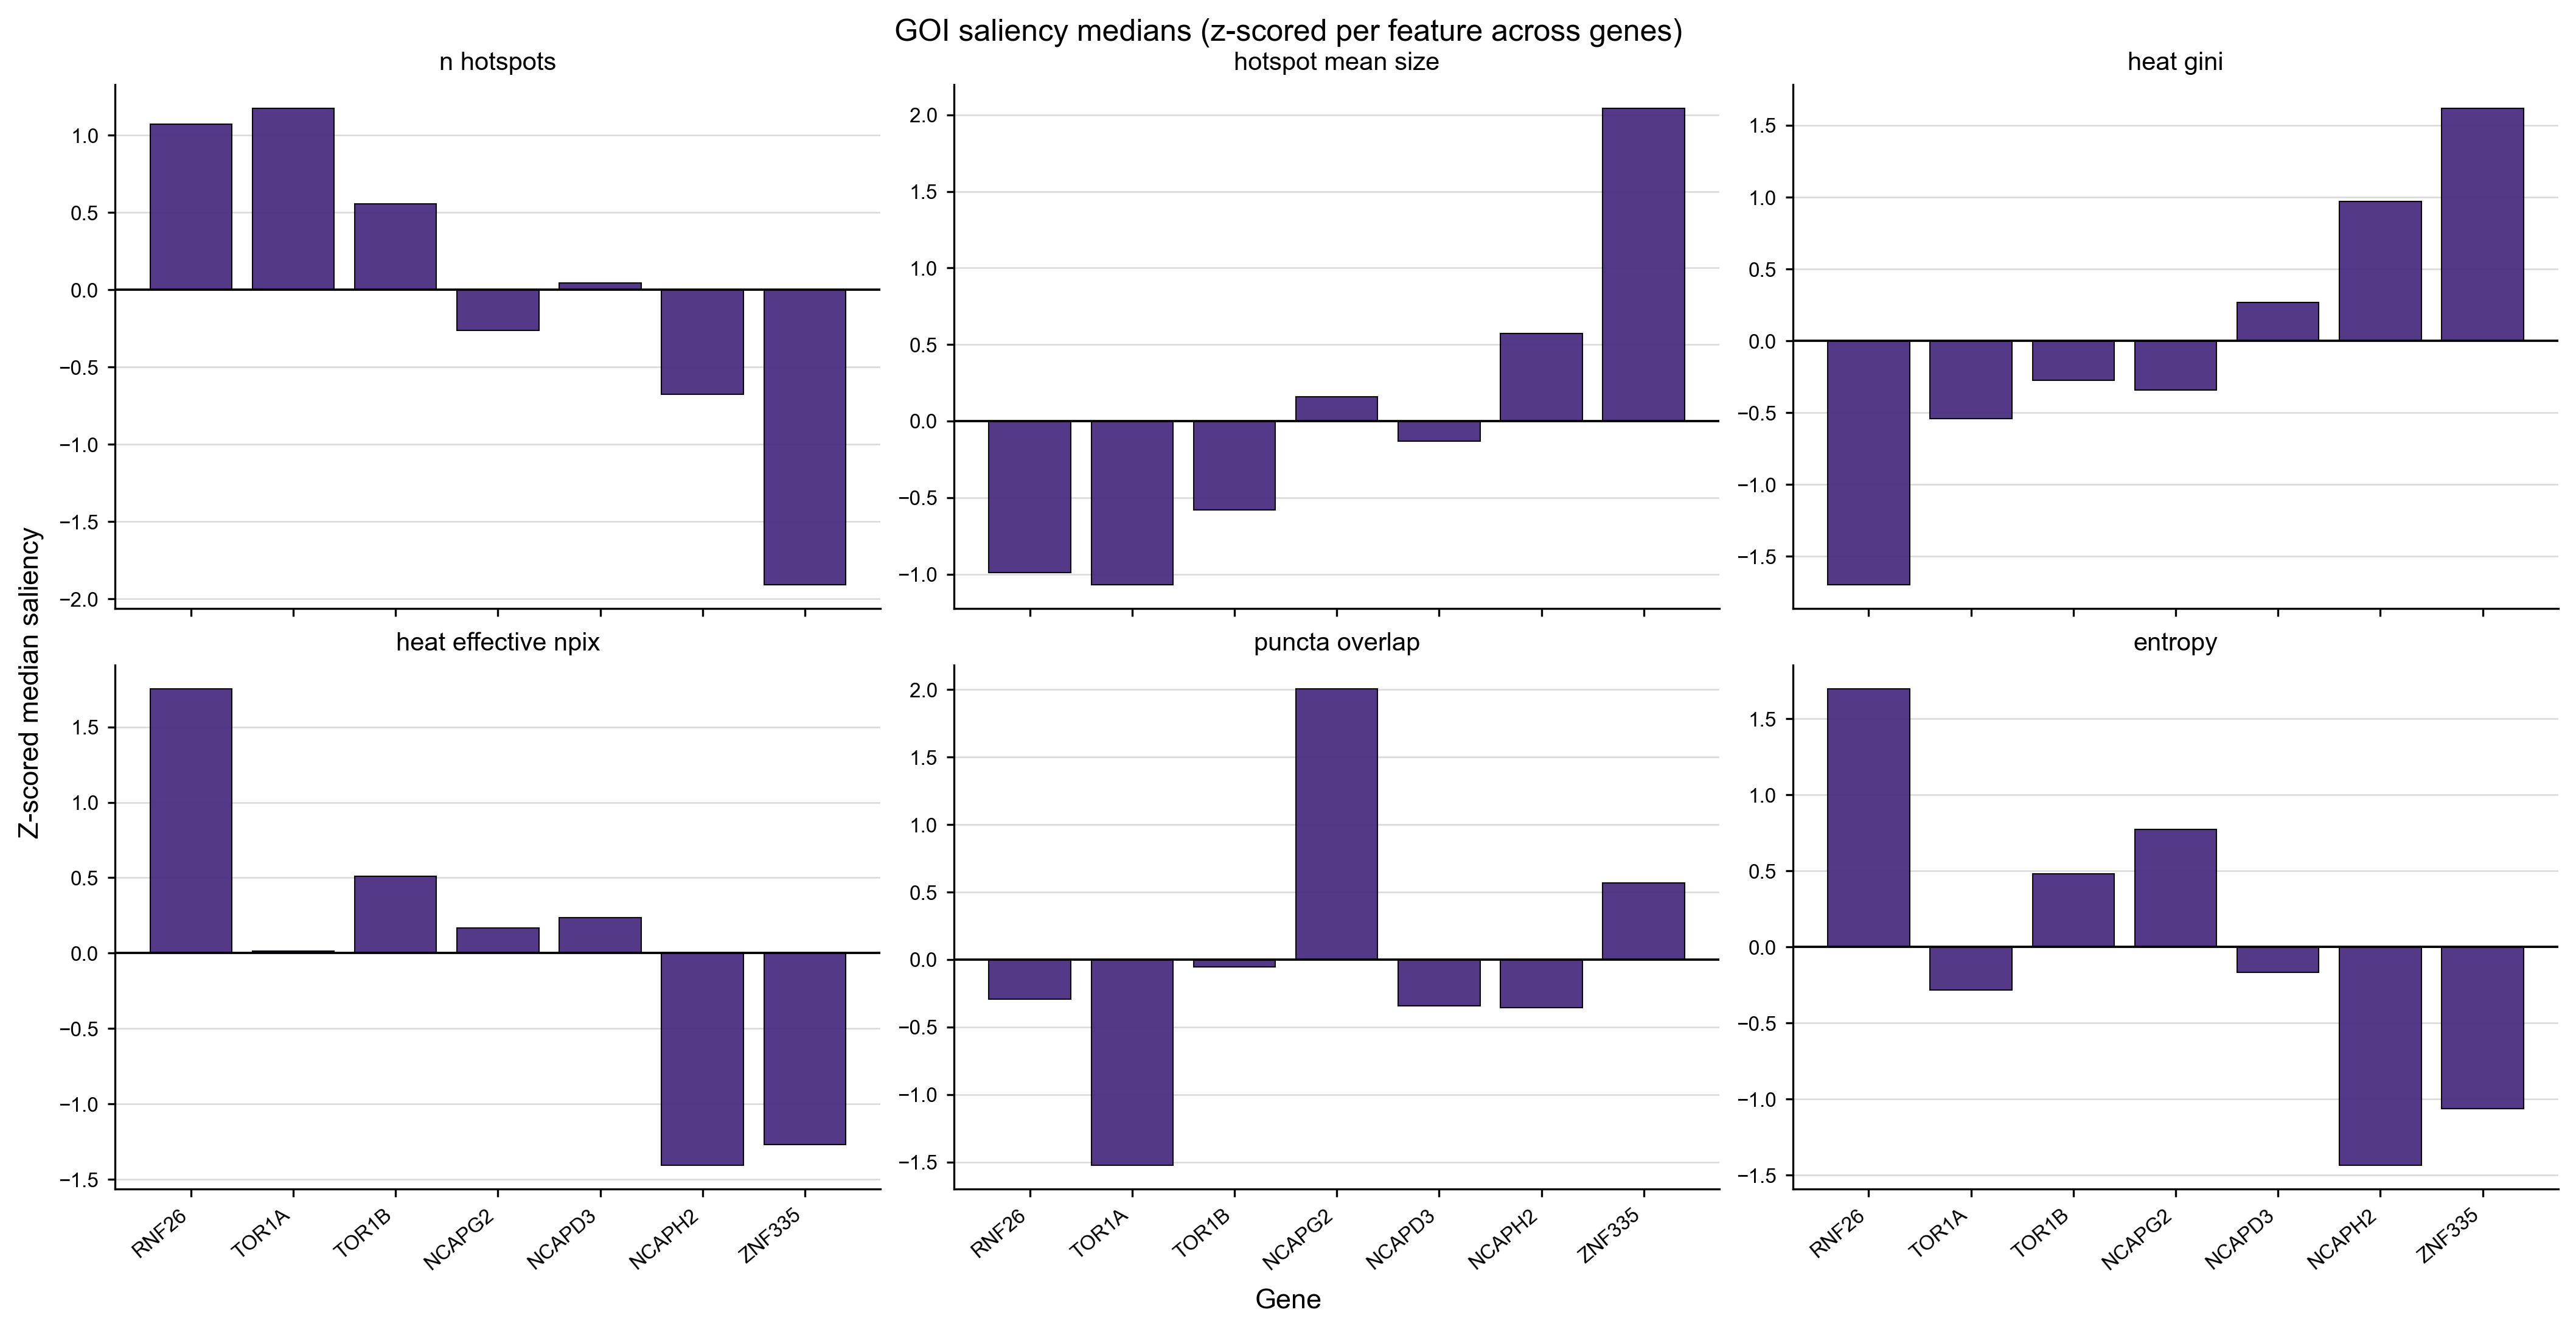

[OK] Saved:
 - saliency_GOI\GOI_saliency_medians_panels_zscore.png
 - saliency_GOI\GOI_saliency_medians_panels_zscore.pdf


In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# -----------------------------
# Config
# -----------------------------
SAL_OUTDIR = "saliency_GOI"
MEDIANS_XLSX = os.path.join(SAL_OUTDIR, "GOI_saliency_medians_only.xlsx")

OUT_PNG = os.path.join(SAL_OUTDIR, "GOI_saliency_medians_panels_zscore.png")
OUT_PDF = os.path.join(SAL_OUTDIR, "GOI_saliency_medians_panels_zscore.pdf")

FEATURES = [
    "n_hotspots_median",
    "hotspot_mean_size_median",
    "heat_gini_median",
    "heat_effective_npix_median",
    "puncta_overlap_median",
    "entropy_median",
]

# Optional: force a specific gene order
GENE_ORDER = ["RNF26", "TOR1A", "TOR1B", "NCAPG2", "NCAPD3", "NCAPH2", "ZNF335", "NT"]

# -----------------------------
# Load medians-only table
# -----------------------------
df_med = pd.read_excel(MEDIANS_XLSX)

keep_cols = ["gene"] + FEATURES
missing = [c for c in keep_cols if c not in df_med.columns]
if missing:
    raise ValueError(f"Missing columns in {MEDIANS_XLSX}: {missing}")

df_med = df_med[keep_cols].copy()

# Order genes (optional)
if GENE_ORDER is not None:
    df_med["gene"] = pd.Categorical(df_med["gene"], categories=GENE_ORDER, ordered=True)
    df_med = df_med.sort_values("gene")
else:
    df_med = df_med.sort_values("gene")

genes = df_med["gene"].astype(str).tolist()

# -----------------------------
# Z-score per feature across genes (recommended)
# -----------------------------
Z = StandardScaler().fit_transform(df_med[FEATURES].values)
df_z = pd.DataFrame(Z, columns=FEATURES)
df_z.insert(0, "gene", genes)

# -----------------------------
# Plot: 2x3 panels (one feature per panel)
# -----------------------------
import matplotlib as mpl
import matplotlib.pyplot as plt

# -----------------------------
# Plot
# -----------------------------
mpl.rcParams.update({
    "font.family": "Arial",        
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,

    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3,
    "ytick.major.size": 3,

    # vector/PDF friendliness
    "pdf.fonttype": 42,
    "ps.fonttype": 42,

    "figure.dpi": 300,
    "savefig.dpi": 300,
})

BAR_COLOR = "#4B2E83"   

fig, axes = plt.subplots(
    2, 3,
    figsize=(14, 7),
    sharex=True,
    constrained_layout=True
)
axes = axes.flatten()

# genes = list(df_z["gene"])
genes = df_z["gene"].tolist()

for ax, feat in zip(axes, FEATURES):
    y = df_z[feat].values

    ax.bar(
        genes, y,
        color=BAR_COLOR,
        edgecolor="black",
        linewidth=0.5,
        alpha=0.95,
        zorder=3
    )

    ax.axhline(0, color="black", lw=0.9, zorder=4)

    ax.grid(axis="y", color="0.85", linewidth=0.6, zorder=0)
    ax.set_axisbelow(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    nice = feat.replace("_median", "").replace("_", " ")
    ax.set_title(nice)

    ax.tick_params(axis="x", rotation=40)
    for tick in ax.get_xticklabels():
        tick.set_horizontalalignment("right")

fig.suptitle("GOI saliency medians (z-scored per feature across genes)", y=1.02, fontsize=12)
fig.supxlabel("Gene")
fig.supylabel("Z-scored median saliency")

# Save
fig.savefig(OUT_PNG, bbox_inches="tight")
fig.savefig(OUT_PDF, bbox_inches="tight")
plt.show()

print("[OK] Saved:")
print(" -", OUT_PNG)
print(" -", OUT_PDF)


In [8]:
# ==== Full Evaluation & Training Plots (6-panel + individual saves) ====
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt, torch
from sklearn.metrics import (
    mean_absolute_error, r2_score, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, roc_curve, roc_auc_score
)
from scipy.stats import pearsonr

# -----------------------------
# Config
# -----------------------------
CKPT = "similarity_model_best.pt"
custom_colors = ["#f2704e", "#e13c3d", "#921d5c", "#651f56"]

# -----------------------------
# Collect predictions
# -----------------------------
y_true, y_pred = [], []
model.eval()
with torch.no_grad():
    for xb, yb in val_loader:
        xb, yb = xb.to(device), yb.to(device).unsqueeze(1)
        preds = model(xb)
        y_true.extend(yb.cpu().numpy().ravel())
        y_pred.extend(preds.cpu().numpy().ravel())
y_true, y_pred = np.array(y_true), np.array(y_pred)

# -----------------------------
# Metrics
# -----------------------------
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)
corr = pearsonr(y_true, y_pred)[0] if len(y_true) > 1 else np.nan
y_pred_class = np.rint(y_pred).astype(int)
acc = accuracy_score(y_true, y_pred_class)
cm  = confusion_matrix(y_true, y_pred_class, labels=[-1,0,1])

mask_bin = np.isin(y_true, [-1,1])
roc_auc, fpr, tpr = np.nan, None, None
if mask_bin.sum() > 0:
    y_true_bin = (y_true[mask_bin] == 1).astype(int)
    y_score_bin = y_pred[mask_bin]
    roc_auc = roc_auc_score(y_true_bin, y_score_bin)
    fpr, tpr, _ = roc_curve(y_true_bin, y_score_bin)

print("="*60)
print(f"MAE={mae:.4f}, R²={r2:.4f}, Corr={corr:.4f}, Acc={acc:.4f}, AUC={roc_auc:.4f}")

# -----------------------------
# Training history
# -----------------------------
hist = None
if "train_history" in globals() and len(train_history) > 0:
    hist = pd.DataFrame(train_history)

# -----------------------------
# 6-panel summary
# -----------------------------
fig, axes = plt.subplots(3, 2, figsize=(12, 15))

# 1. Scatter
color_map = {-1: custom_colors[0], 0: custom_colors[1], 1: custom_colors[2]}
axes[0,0].scatter(y_true, y_pred, c=[color_map[int(lbl)] for lbl in y_true],
                  alpha=0.6, edgecolor="k")
for h in [-1,0,1]:
    axes[0,0].axhline(h, color='grey', linestyle='--')
    axes[0,0].axvline(h, color='grey', linestyle='--')
axes[0,0].set_title(f"True vs Predicted (Corr={corr:.2f})")

# 2. Histogram
for i,(cls,label) in enumerate([(-1,"RNF26 (-1)"), (0,"Neutral (0)"), (1,"ZNF335 (+1)")]):
    axes[0,1].hist(y_pred[y_true==cls], bins=20, alpha=0.8,
                   label=label, color=custom_colors[i])
axes[0,1].set_title("Prediction Distribution"); axes[0,1].legend()

# 3. ROC
if fpr is not None:
    axes[1,0].plot(fpr, tpr, lw=2, color=custom_colors[3])
    axes[1,0].plot([0,1],[0,1],'--',color='grey')
    axes[1,0].text(0.05, 0.95, f"AUC = {roc_auc:.3f}",
                   transform=axes[1,0].transAxes, va="top", ha="left",
                   bbox=dict(facecolor="white", edgecolor="black", boxstyle="round,pad=0.3"))
    axes[1,0].set_title("ROC Curve (RNF26 vs ZNF335)")

# 4. Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
    display_labels=['RNF26 (-1)','Neutral (0)','ZNF335 (+1)'])
disp.plot(ax=axes[1,1], cmap="BuPu", colorbar=False)
axes[1,1].set_title("Confusion Matrix")

# 5. Loss Curve
if hist is not None:
    axes[2,0].plot(hist["epoch"], hist["train_loss"], label="Train Loss", color=custom_colors[3])
    axes[2,0].plot(hist["epoch"], hist["val_loss"], label="Val Loss", color=custom_colors[0])
    min_idx = hist["val_loss"].idxmin()
    axes[2,0].scatter(hist["epoch"][min_idx], hist["val_loss"][min_idx], color="black")
    axes[2,0].text(hist["epoch"][min_idx], hist["val_loss"][min_idx],
                   f"Min Val Loss={hist['val_loss'][min_idx]:.3f}\n(Epoch {hist['epoch'][min_idx]})",
                   fontsize=9, va="bottom", ha="left",
                   bbox=dict(facecolor="white", edgecolor="black", boxstyle="round,pad=0.3"))
    axes[2,0].set_title("Loss Curve"); axes[2,0].legend()

# 6. Accuracy Curve
if hist is not None and "val_acc" in hist:
    axes[2,1].plot(hist["epoch"], hist["val_acc"], label="Val Accuracy", color=custom_colors[2])
    max_idx = hist["val_acc"].idxmax()
    axes[2,1].scatter(hist["epoch"][max_idx], hist["val_acc"][max_idx], color="black")
    axes[2,1].text(hist["epoch"][max_idx], hist["val_acc"][max_idx],
                   f"Max Val Acc={hist['val_acc'][max_idx]:.3f}\n(Epoch {hist['epoch'][max_idx]})",
                   fontsize=9, va="bottom", ha="left",
                   bbox=dict(facecolor="white", edgecolor="black", boxstyle="round,pad=0.3"))
    axes[2,1].set_title("Validation Accuracy"); axes[2,1].legend()

plt.tight_layout()
fig.savefig("evaluation_training_summary_full.pdf", dpi=300)
plt.close(fig)


# -----------------------------
# Individual plots (regenerate fresh)
# -----------------------------
def save_single_plot(fname, plot_func):
    fig, ax = plt.subplots(figsize=(6,5))
    plot_func(ax)
    fig.savefig(fname, dpi=300, bbox_inches="tight")
    plt.close(fig)

save_single_plot("scatter_only.pdf", lambda ax: ax.scatter(
    y_true, y_pred, c=[color_map[int(lbl)] for lbl in y_true],
    alpha=0.6, edgecolor="k"))

save_single_plot("hist_only.pdf", lambda ax: [
    ax.hist(y_pred[y_true==cls], bins=20, alpha=0.8, label=label, color=custom_colors[i])
    for i,(cls,label) in enumerate([(-1,"RNF26"),(0,"Neutral"),(1,"ZNF335")])
])

if fpr is not None:
    save_single_plot("roc_only.pdf", lambda ax: [
        ax.plot(fpr, tpr, lw=2, color=custom_colors[3]),
        ax.plot([0,1],[0,1],'--',color='grey'),
        ax.text(0.05, 0.95, f"AUC={roc_auc:.3f}", transform=ax.transAxes,
                va="top", ha="left",
                bbox=dict(facecolor="white", edgecolor="black", boxstyle="round,pad=0.3"))
    ])

# Corrected confusion matrix save
save_single_plot("cm_only.pdf", lambda ax: ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['RNF26 (-1)','Neutral (0)','ZNF335 (+1)']
).plot(ax=ax, cmap="BuPu", colorbar=False))

if hist is not None:
    save_single_plot("loss_only.pdf", lambda ax: [
        ax.plot(hist["epoch"], hist["train_loss"], label="Train", color=custom_colors[3]),
        ax.plot(hist["epoch"], hist["val_loss"], label="Val", color=custom_colors[0]),
        ax.legend()
    ])
    if "val_acc" in hist:
        save_single_plot("acc_only.pdf", lambda ax: [
            ax.plot(hist["epoch"], hist["val_acc"], label="Val Acc", color=custom_colors[2]),
            ax.legend()
        ])


MAE=0.3960, R²=0.5645, Corr=0.7561, Acc=0.7041, AUC=0.9494


In [9]:
import pandas as pd
import numpy as np

# Load both files
sim_df = pd.read_excel("gene_similarity_predictions_inferenceFullList.xlsx")
zscore_df = pd.read_excel("Zscore.xlsx")

# Standardize gene column
sim_df.rename(columns={sim_df.columns[0]: "Gene"}, inplace=True)
zscore_df.rename(columns={zscore_df.columns[0]: "Gene"}, inplace=True)

# Merge in Z-Score
merged = pd.merge(sim_df, zscore_df[["Gene", "Z-Score"]], on="Gene", how="left")

# Keep only desired columns
keep_cols = [
    "Gene", "sim_ZNF335", "sim_B02", "sim_RNF26",
    "relative_score", "diff_ZNF335_B02", "diff_B02_RNF26",
    "n_cells", "Z-Score"
]
merged = merged[keep_cols]

# Keep only one row per Gene: highest Z-Score if present,
# otherwise just the first available row
merged = (
    merged.sort_values("Z-Score", ascending=False, na_position="last")
    .groupby("Gene")
    .head(1)
    .reset_index(drop=True)
)

# Add normalization (0–100) and rank columns
for col in ["sim_ZNF335", "sim_B02", "sim_RNF26"]:
    # Linear normalization 0–100
    merged[f"{col}_norm100"] = 100 * (merged[col] - merged[col].min()) / (merged[col].max() - merged[col].min())
    
    # Integer rank (1 = most similar, highest value first)
    merged[f"{col}_rank"] = merged[col].rank(method="min", ascending=False).astype(int)

# Save
out_file = "final_similarity_with_ranks.xlsx"
merged.to_excel(out_file, index=False)

print(f"Saved {out_file}")


Saved final_similarity_with_ranks.xlsx


C:\Users\Schlieker Lab\AppData\Roaming\Python\Python311\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\Schlieker Lab\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


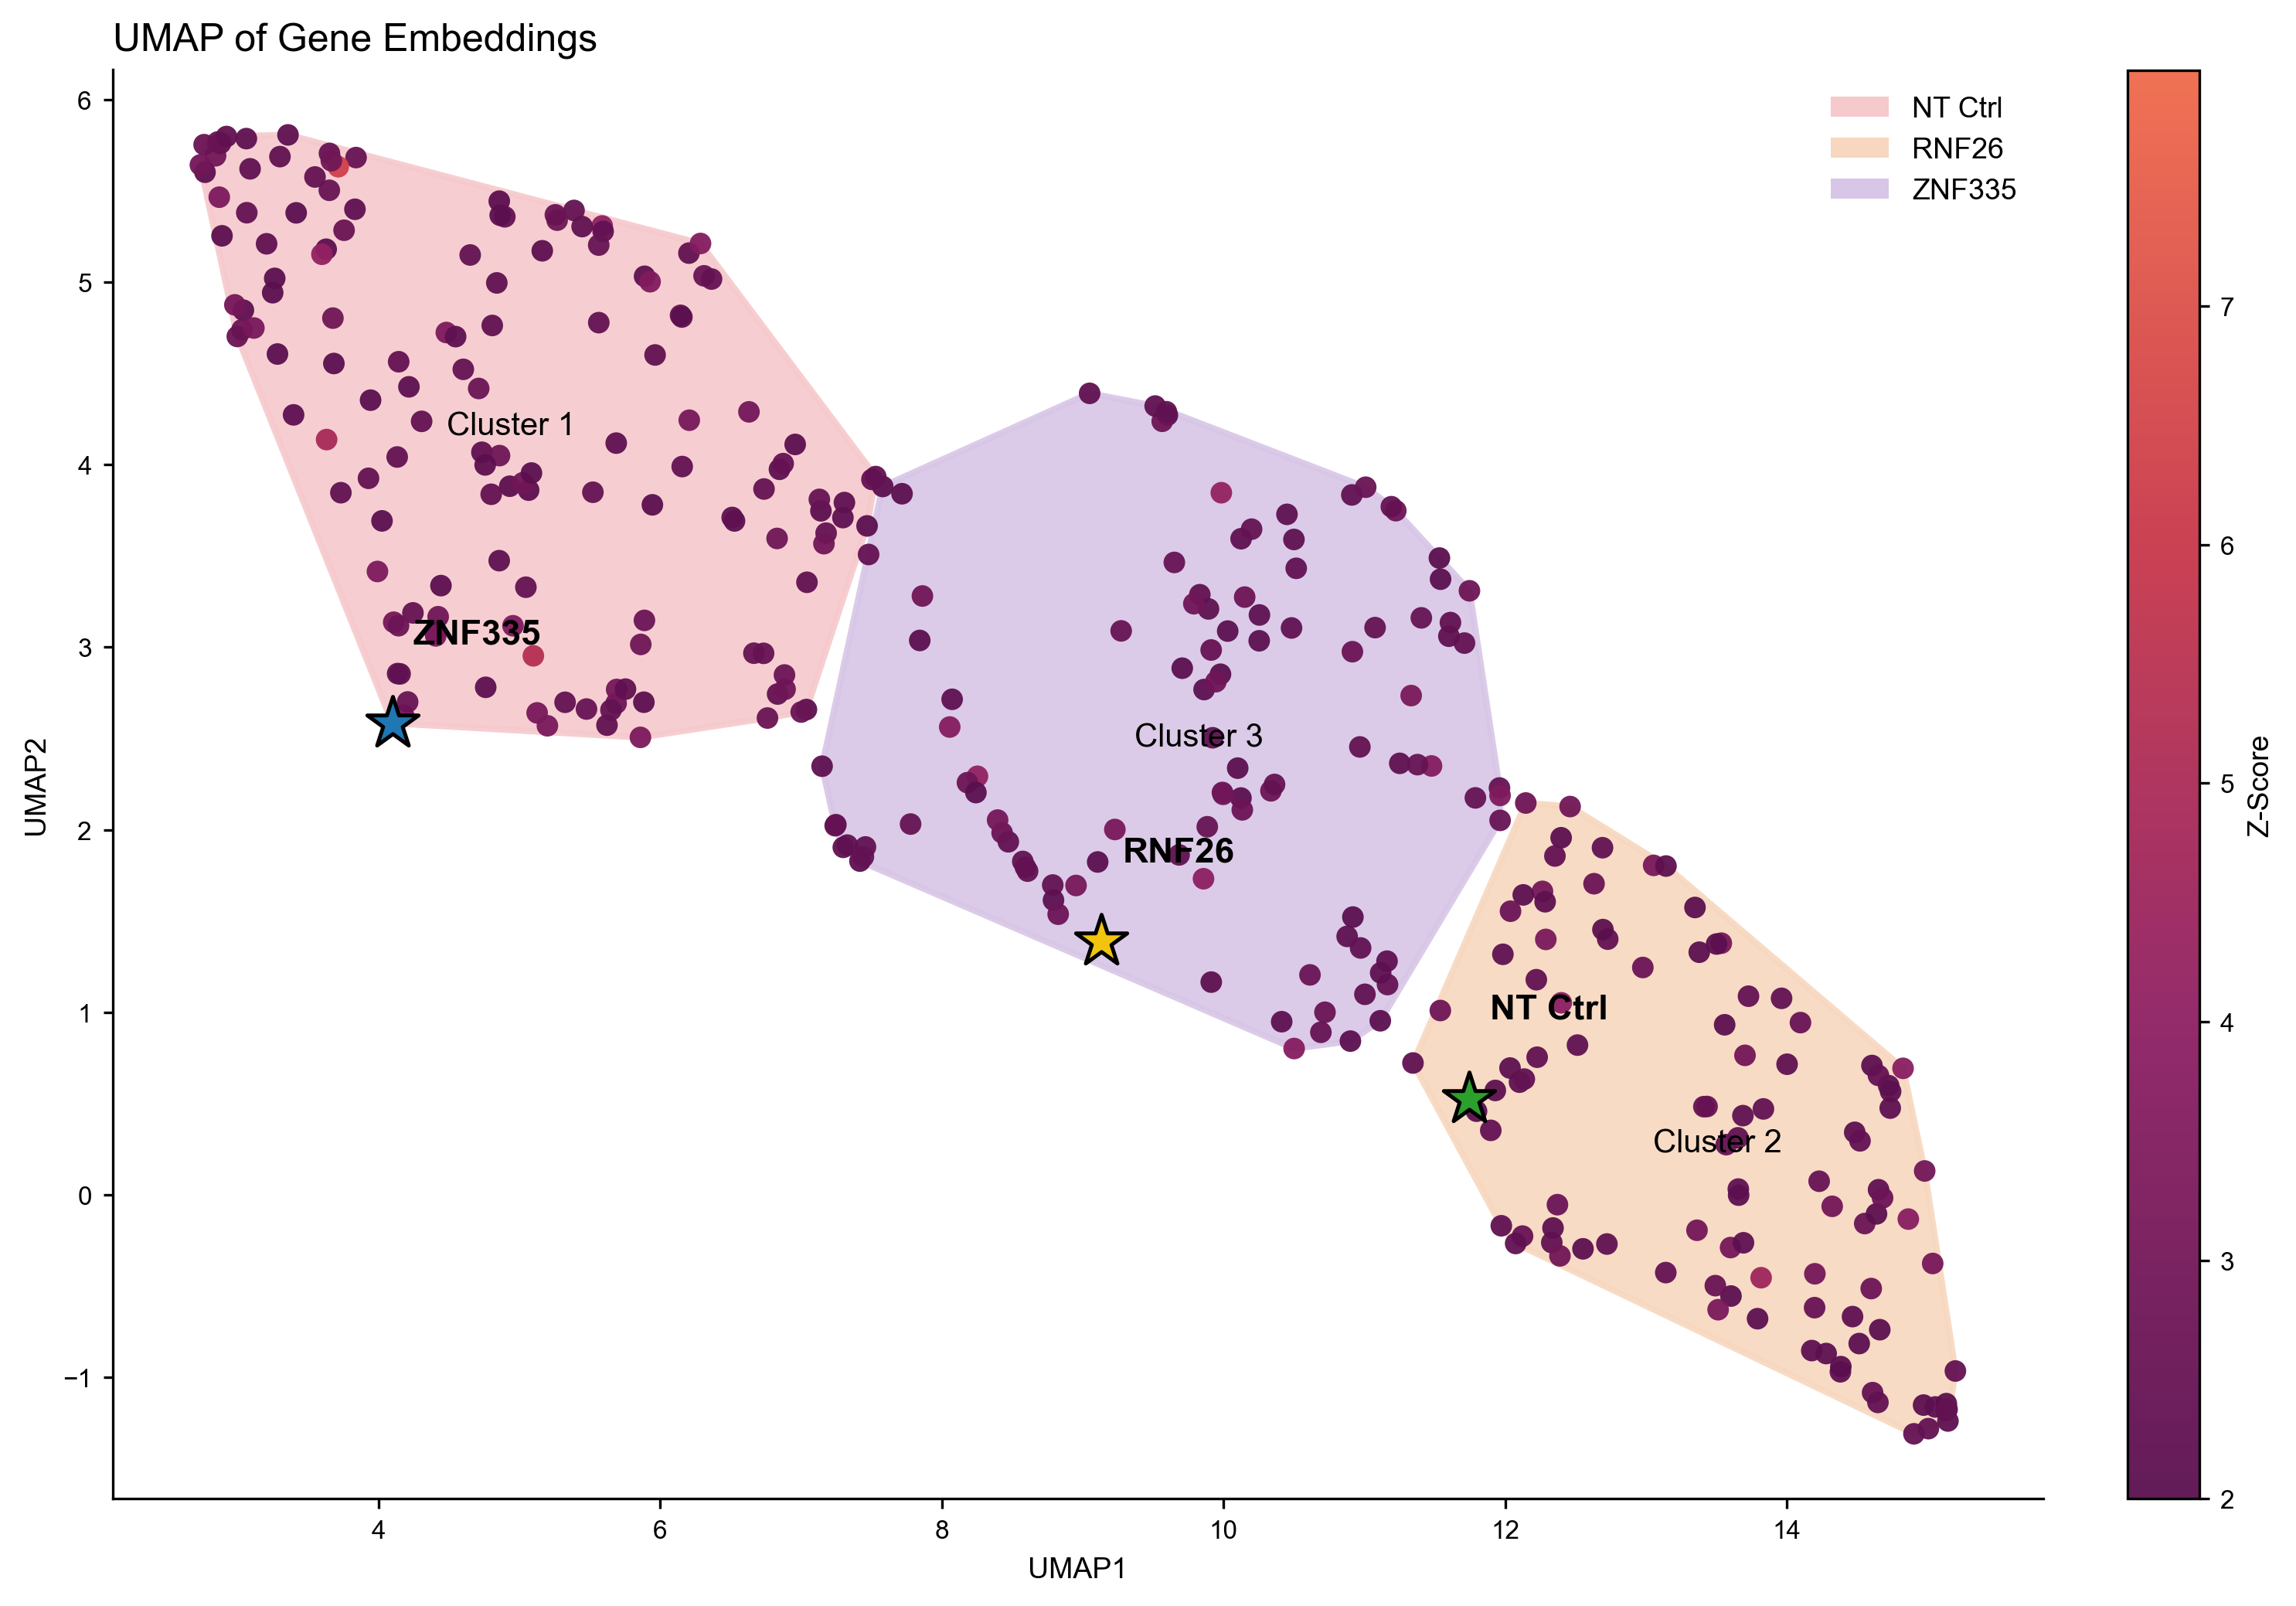

In [85]:
# UMAP gene-centroids + 3-cluster hulls + Z-score coloring (clean, minimal)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.spatial import ConvexHull

# -----------------------------
# Config
# -----------------------------
XLSX = "final_similarity_with_ranks.xlsx"

ANCHORS = ["AC0559_B02", "RNF26", "ZNF335"]
ANCHOR_LABEL = {"AC0559_B02": "NT Ctrl", "RNF26": "RNF26", "ZNF335": "ZNF335"}
ANCHOR_COLORS = {"AC0559_B02": "#2ca02c", "RNF26": "#f1c40f", "ZNF335": "#1f77b4"}

CLUSTER_FILL = {0: "#f6c9cc", 1: "#f7d7bf", 2: "#d7c6e6"}  # left/mid/right (after remap)

Z_CMAP = LinearSegmentedColormap.from_list(
    "zscore_ref", ["#5b0f4f", "#8e1f63", "#c8374a", "#f06a4b"], N=256
)

# -----------------------------
# Inputs
#   - gene_centroids : dict {gene -> (512,) embedding centroid}
#   - Excel file has columns: Gene, Z-Score
# -----------------------------
gene_df = pd.read_excel(XLSX)
gene_df.columns = gene_df.columns.str.strip()

# Build matrix of centroids
genes = np.array(list(gene_centroids.keys()), dtype=object)
X = np.vstack([gene_centroids[g] for g in genes])

# Drop all *_B02 except AC0559_B02 (your NT anchor)
keep = (~pd.Series(genes).str.endswith("B02").values) | (genes == "AC0559_B02")
genes, X = genes[keep], X[keep]

# -----------------------------
# UMAP (fallback to PCA if umap not installed)
# -----------------------------
try:
    import umap
    Z = umap.UMAP(n_neighbors=10, min_dist=0.1, metric="cosine", random_state=42).fit_transform(X)
except Exception:
    print("UMAP not available; falling back to PCA.")
    Z = PCA(n_components=2, random_state=42).fit_transform(X)

df = pd.DataFrame({"Gene": genes, "UMAP1": Z[:, 0], "UMAP2": Z[:, 1]})
df = df.merge(gene_df[["Gene", "Z-Score"]], on="Gene", how="left")
df.loc[df["Gene"].str.endswith("B02", na=False), "Z-Score"] = np.nan

# -----------------------------
# KMeans clusters in UMAP space
# -----------------------------
df["Cluster"] = KMeans(n_clusters=3, random_state=42, n_init="auto").fit_predict(df[["UMAP1", "UMAP2"]].values)

# Remap cluster IDs so left->0, mid->1, right->2 (for consistent pastel fills)
cent = df.groupby("Cluster")[["UMAP1", "UMAP2"]].mean().sort_values("UMAP1")
remap = {old: new for new, old in enumerate(cent.index.tolist())}

# Safety check anchors
missing = [a for a in ANCHORS if a not in set(df["Gene"])]
if missing:
    raise ValueError(f"Missing anchor(s) in df: {missing}")

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 7))

# cluster hulls
for cid in sorted(df["Cluster"].unique()):
    pts = df.loc[df["Cluster"] == cid, ["UMAP1", "UMAP2"]].values
    if len(pts) < 3:
        continue
    hull = ConvexHull(pts)
    poly = pts[hull.vertices]
    ax.fill(poly[:, 0], poly[:, 1],
            facecolor=CLUSTER_FILL[cid], edgecolor=CLUSTER_FILL[cid],
            alpha=0.9, linewidth=2, zorder=1)
    ax.text(pts[:, 0].mean(), pts[:, 1].mean(), f"Cluster {cid+1}",
            ha="center", va="center", fontsize=10, color="black", zorder=4)

# points colored by raw Z-score range (no percentile clipping)
vmin = np.nanmin(df["Z-Score"])
vmax = np.nanmax(df["Z-Score"])
sc = ax.scatter(df["UMAP1"], df["UMAP2"],
                c=df["Z-Score"], cmap=Z_CMAP, vmin=vmin, vmax=vmax,
                s=45, alpha=0.95, linewidths=0, zorder=3)

# anchors (stars + labels)
for _, r in df[df["Gene"].isin(ANCHORS)].iterrows():
    g = r["Gene"]
    ax.scatter(r["UMAP1"], r["UMAP2"], s=280, marker="*",
               color=ANCHOR_COLORS[g], edgecolor="black", linewidth=1.2, zorder=6)
    ax.text(r["UMAP1"] + 0.15, r["UMAP2"] + 0.4, ANCHOR_LABEL[g],
            fontsize=11, fontweight="bold", ha="left", va="bottom", zorder=7)

# legend + colorbar
ax.legend(handles=[
    Patch(facecolor=CLUSTER_FILL[0], label="NT Ctrl"),
    Patch(facecolor=CLUSTER_FILL[1], label="RNF26"),
    Patch(facecolor=CLUSTER_FILL[2], label="ZNF335"),
], loc="upper right", frameon=False)

cbar = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Z-Score", rotation=90)

# styling
ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")
ax.set_title("UMAP of Gene Embeddings", loc="left", fontsize=12)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("umap_gene_embeddings_like_reference.pdf", bbox_inches="tight")
plt.show()


C:\Users\Schlieker Lab\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Schlieker Lab\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Schlieker Lab\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Schlieker Lab\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known

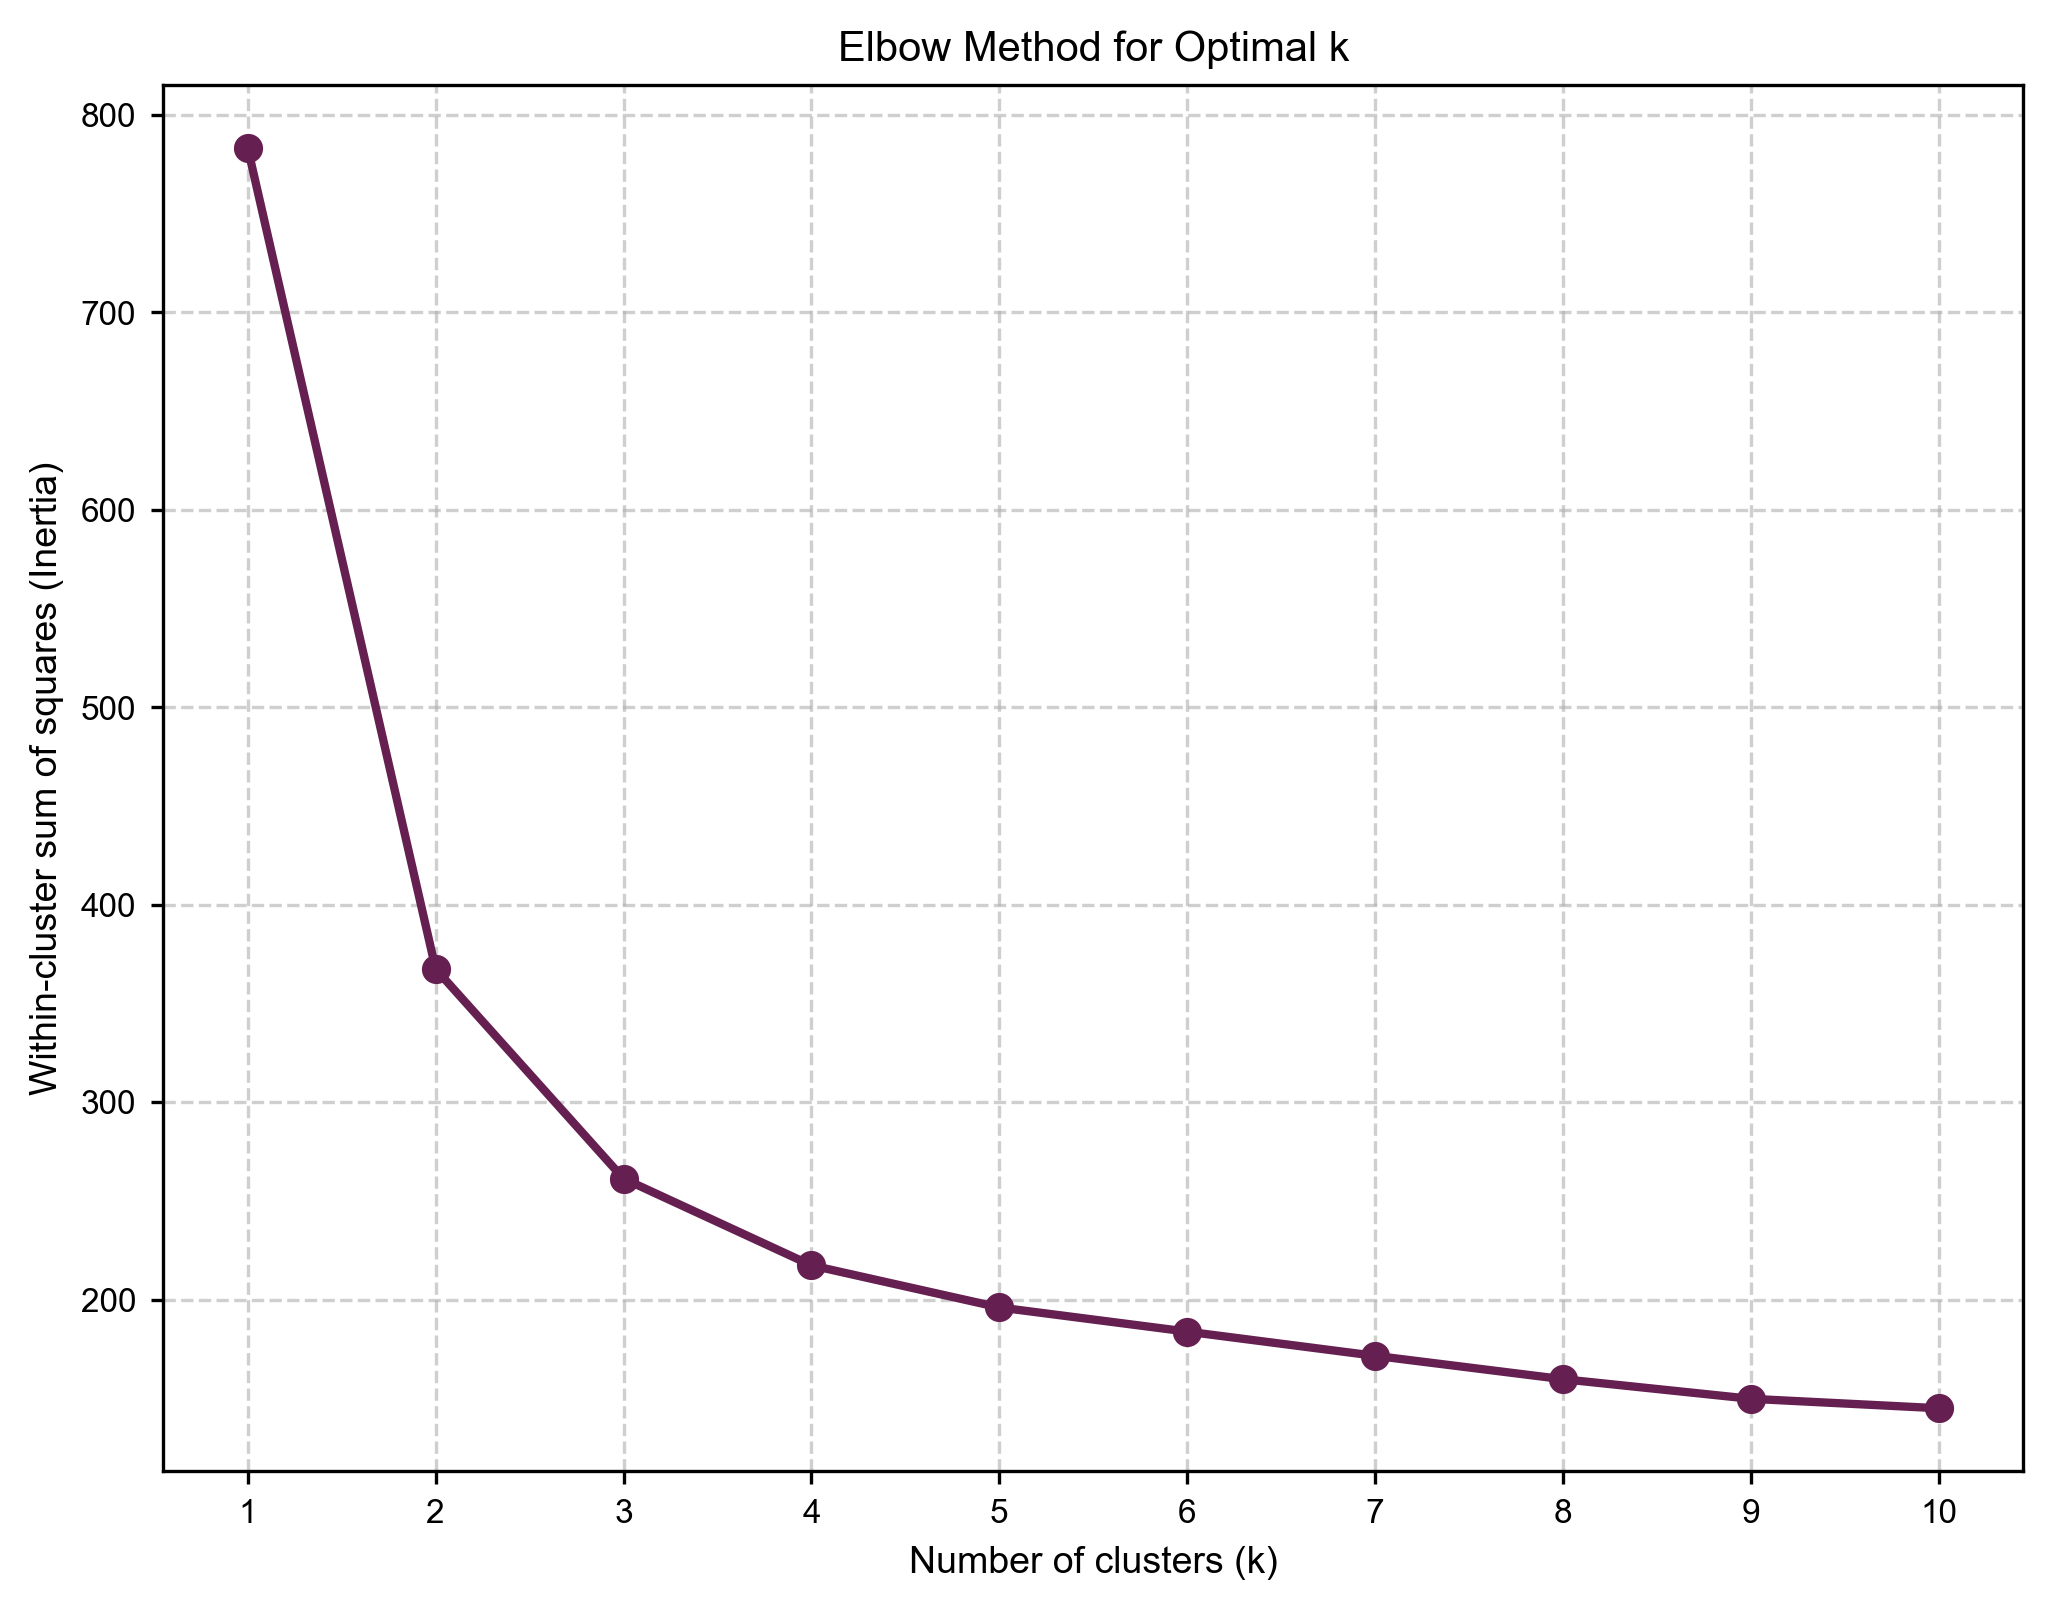

C:\Users\Schlieker Lab\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


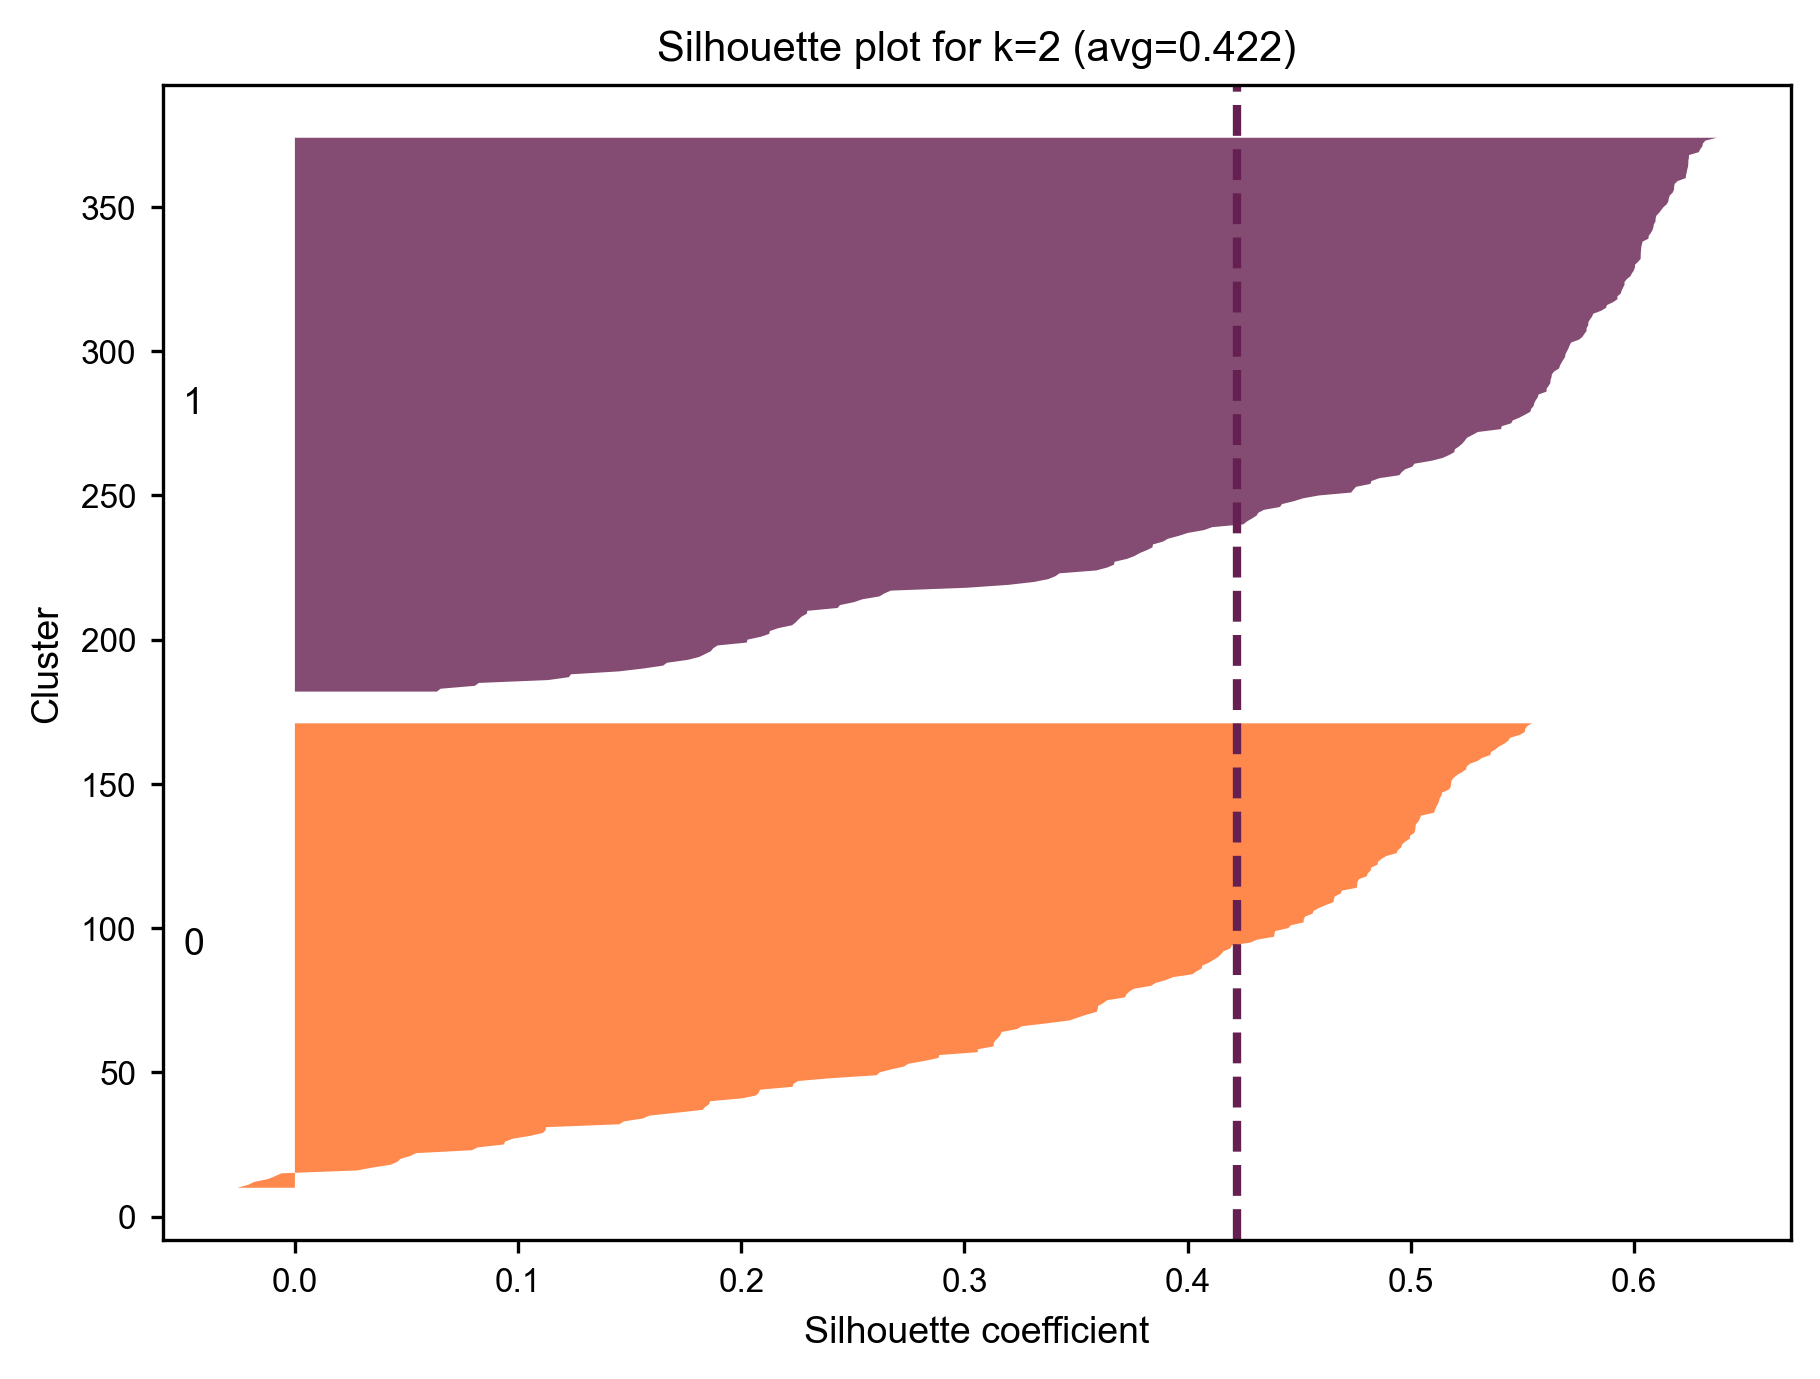

C:\Users\Schlieker Lab\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


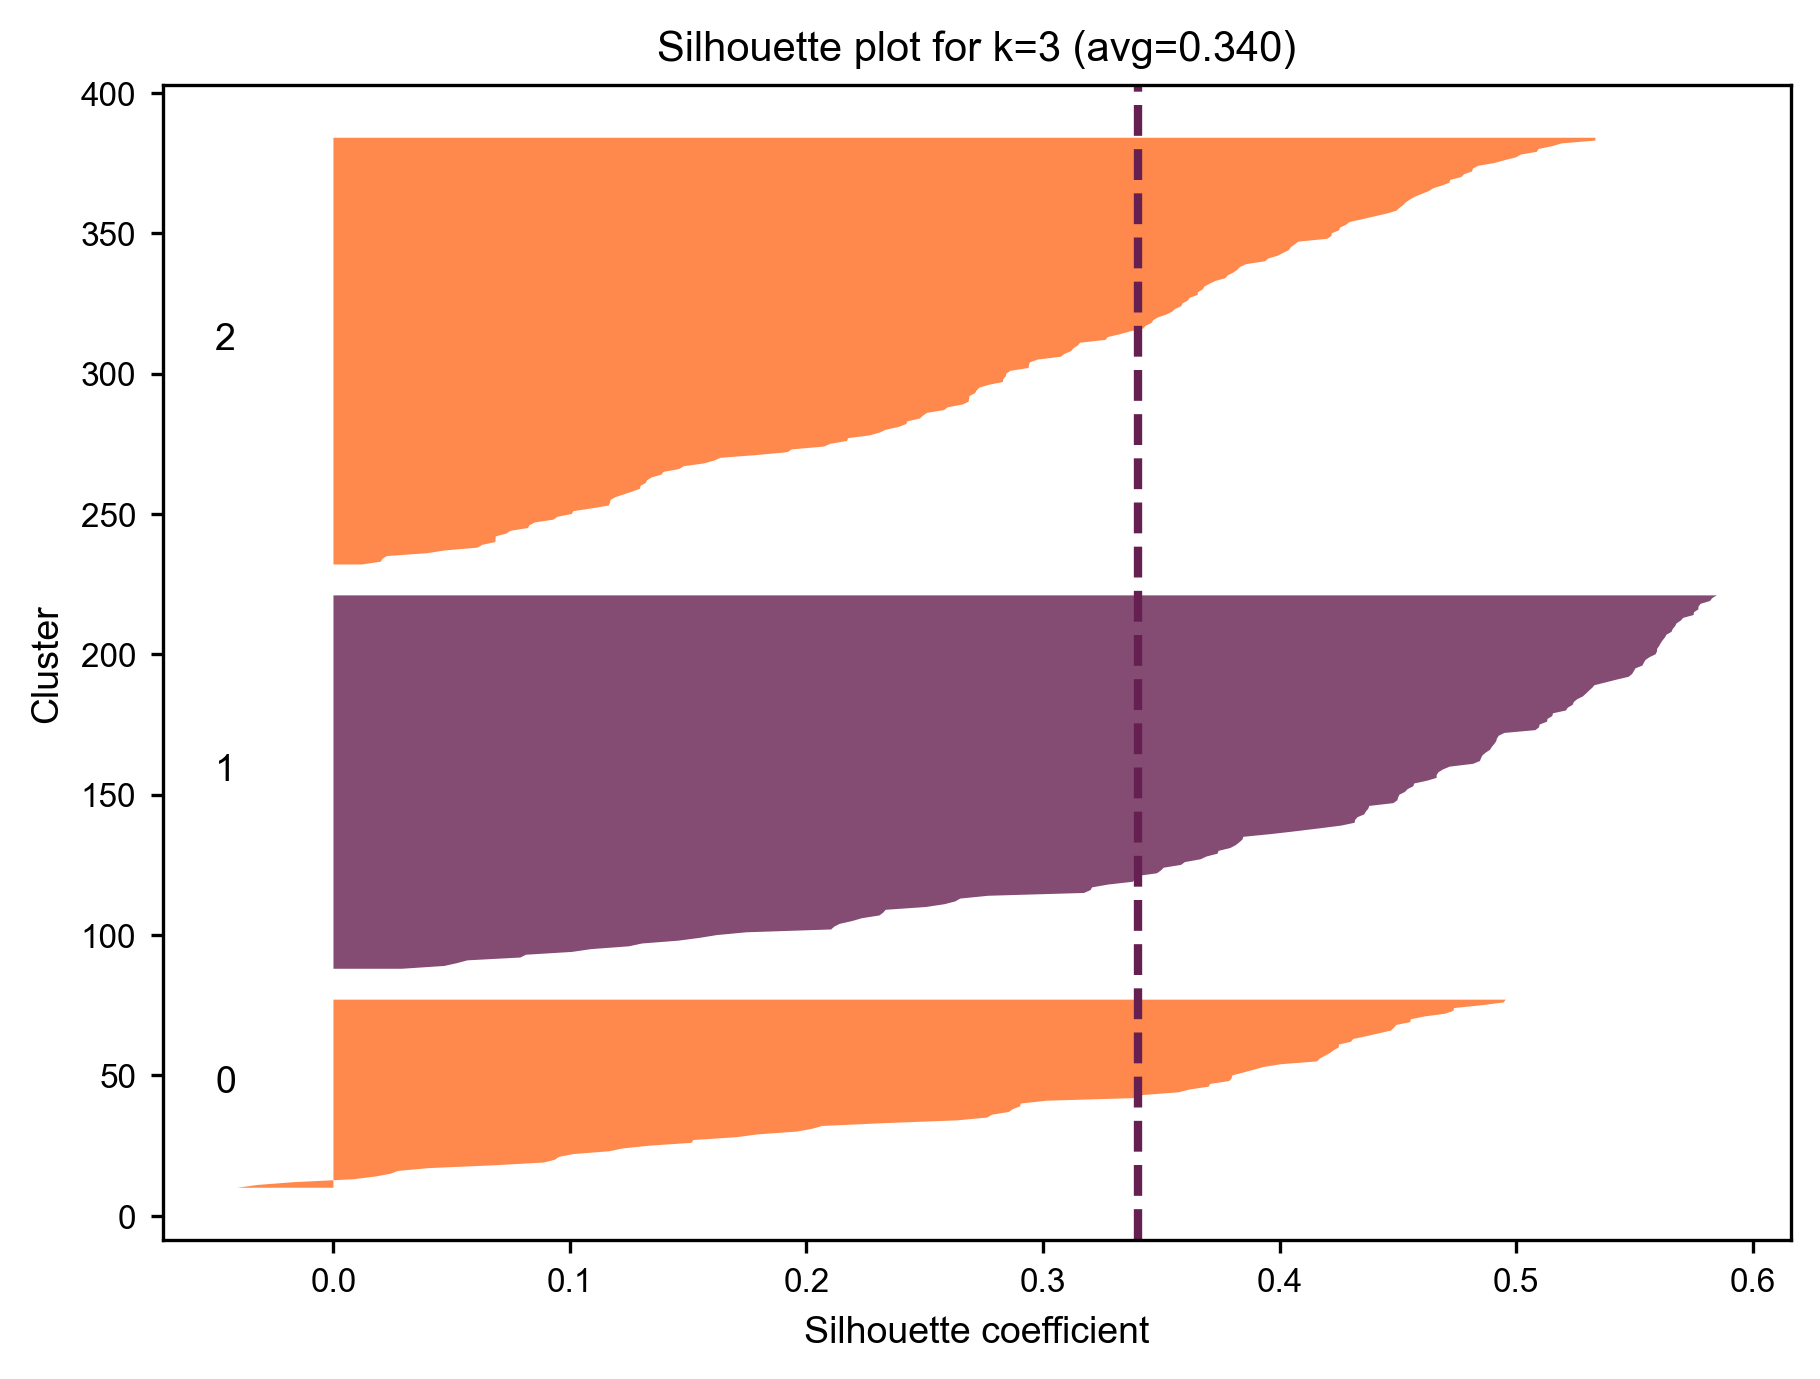

C:\Users\Schlieker Lab\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


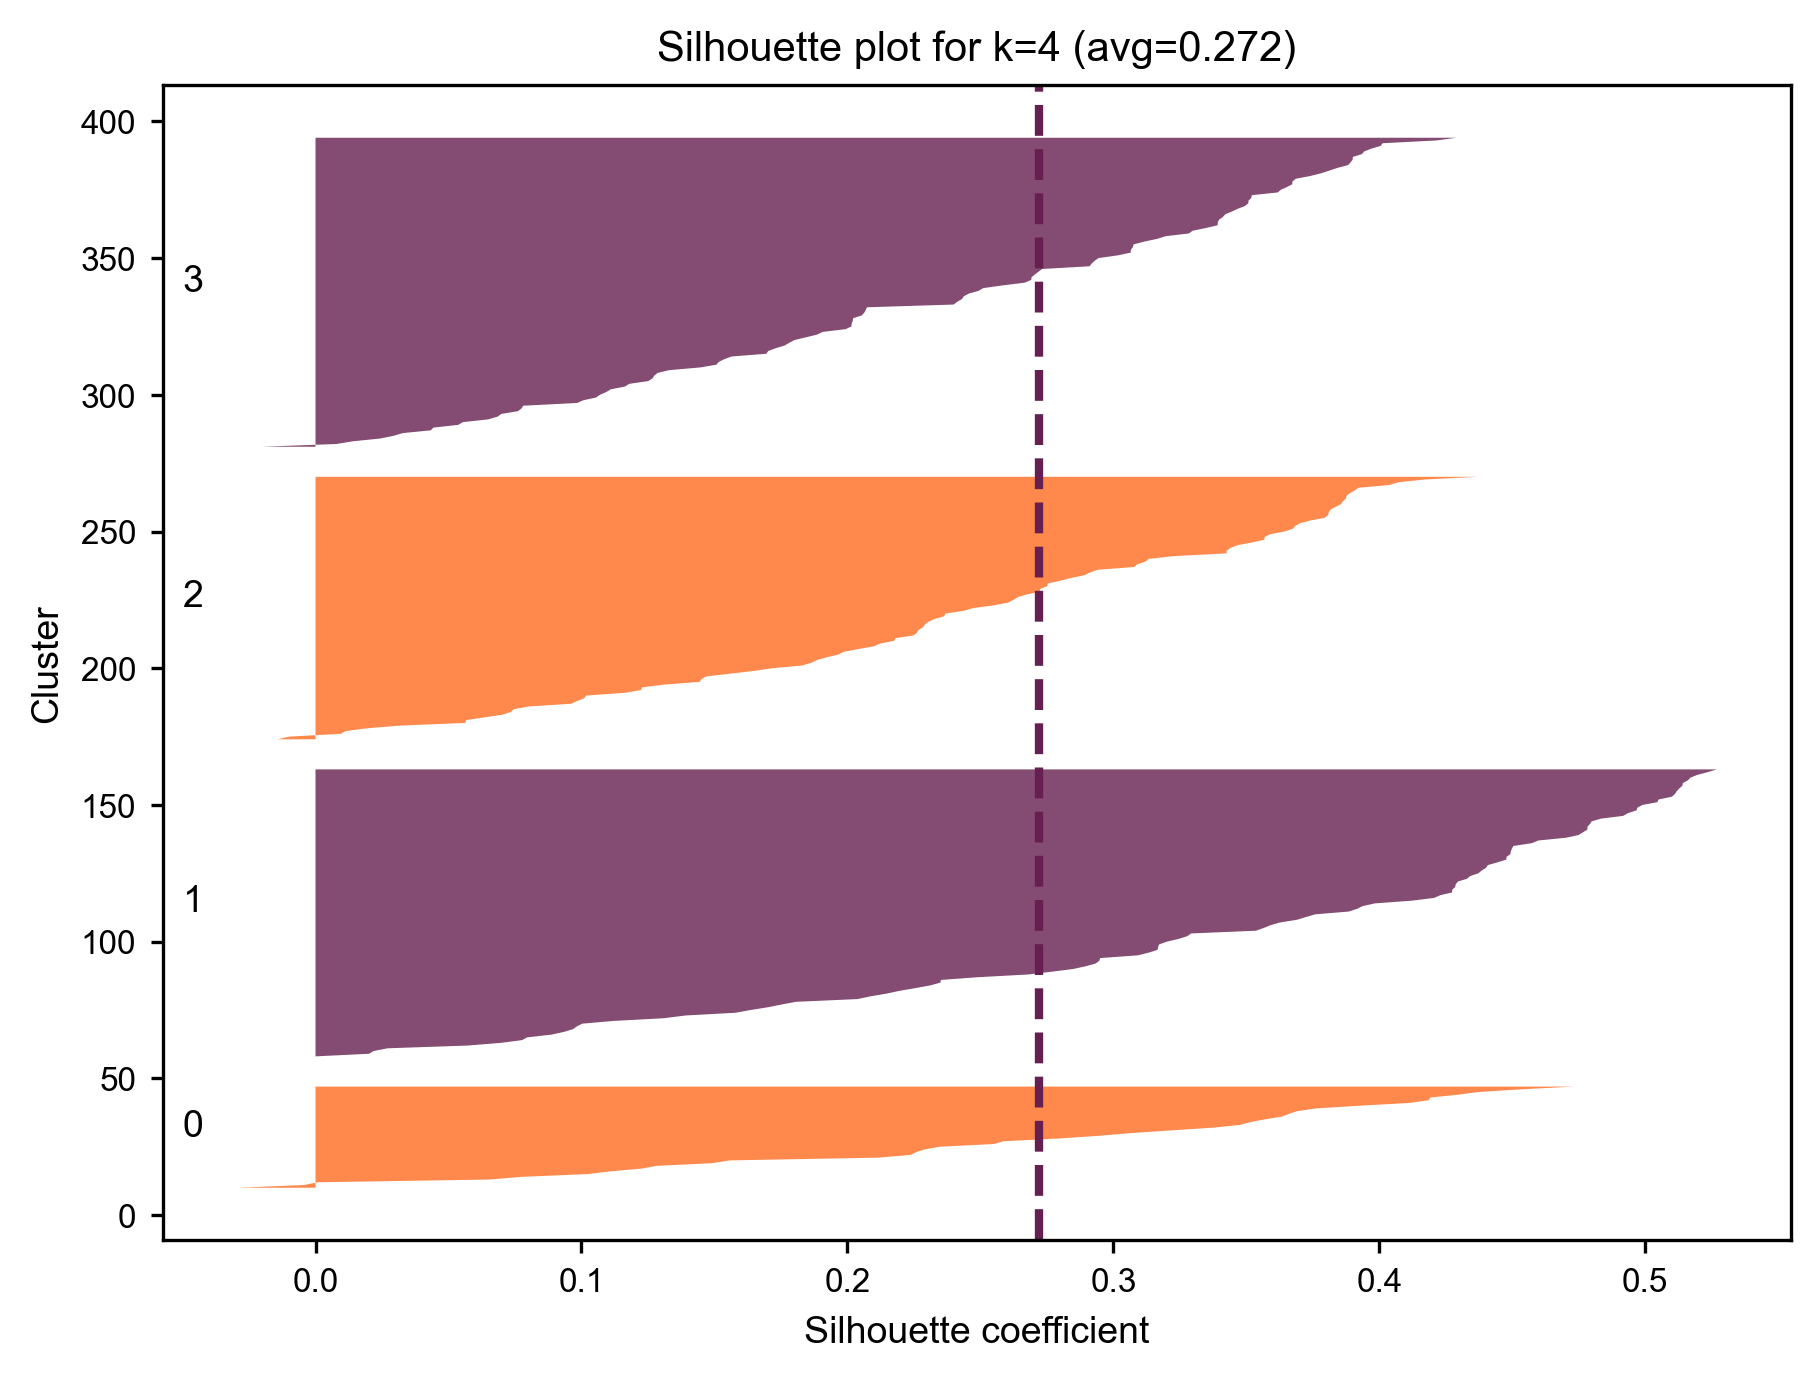

In [87]:
# -----------------------------
# Distance to anchor of SAME cluster (UMAP space)
# -----------------------------

from sklearn.metrics.pairwise import euclidean_distances

anchor_clusters = {}

for a in ANCHORS:
    ax, ay = df.loc[df["Gene"] == a, ["UMAP1", "UMAP2"]].values[0]
    df[f"Dist_to_{ANCHOR_LABEL[a]}"] = np.sqrt(
        (df["UMAP1"] - ax)**2 + (df["UMAP2"] - ay)**2
    )

# Compute distance to the anchor of the same cluster
distances = []

for _, row in df.iterrows():
    gene_cluster = row["Cluster"]

    # find anchor for this cluster
    anchor_for_cluster = None
    for a, c in anchor_clusters.items():
        if c == gene_cluster:
            anchor_for_cluster = a
            break

    if anchor_for_cluster is None:
        distances.append(np.nan)
        continue

    anchor_xy = df.loc[df["Gene"] == anchor_for_cluster, ["UMAP1", "UMAP2"]].values[0]
    gene_xy = row[["UMAP1", "UMAP2"]].values

    distances.append(np.linalg.norm(gene_xy - anchor_xy))


# ---- Save results ----
df.to_excel("gene_cluster_anchor_distances.xlsx", index=False)


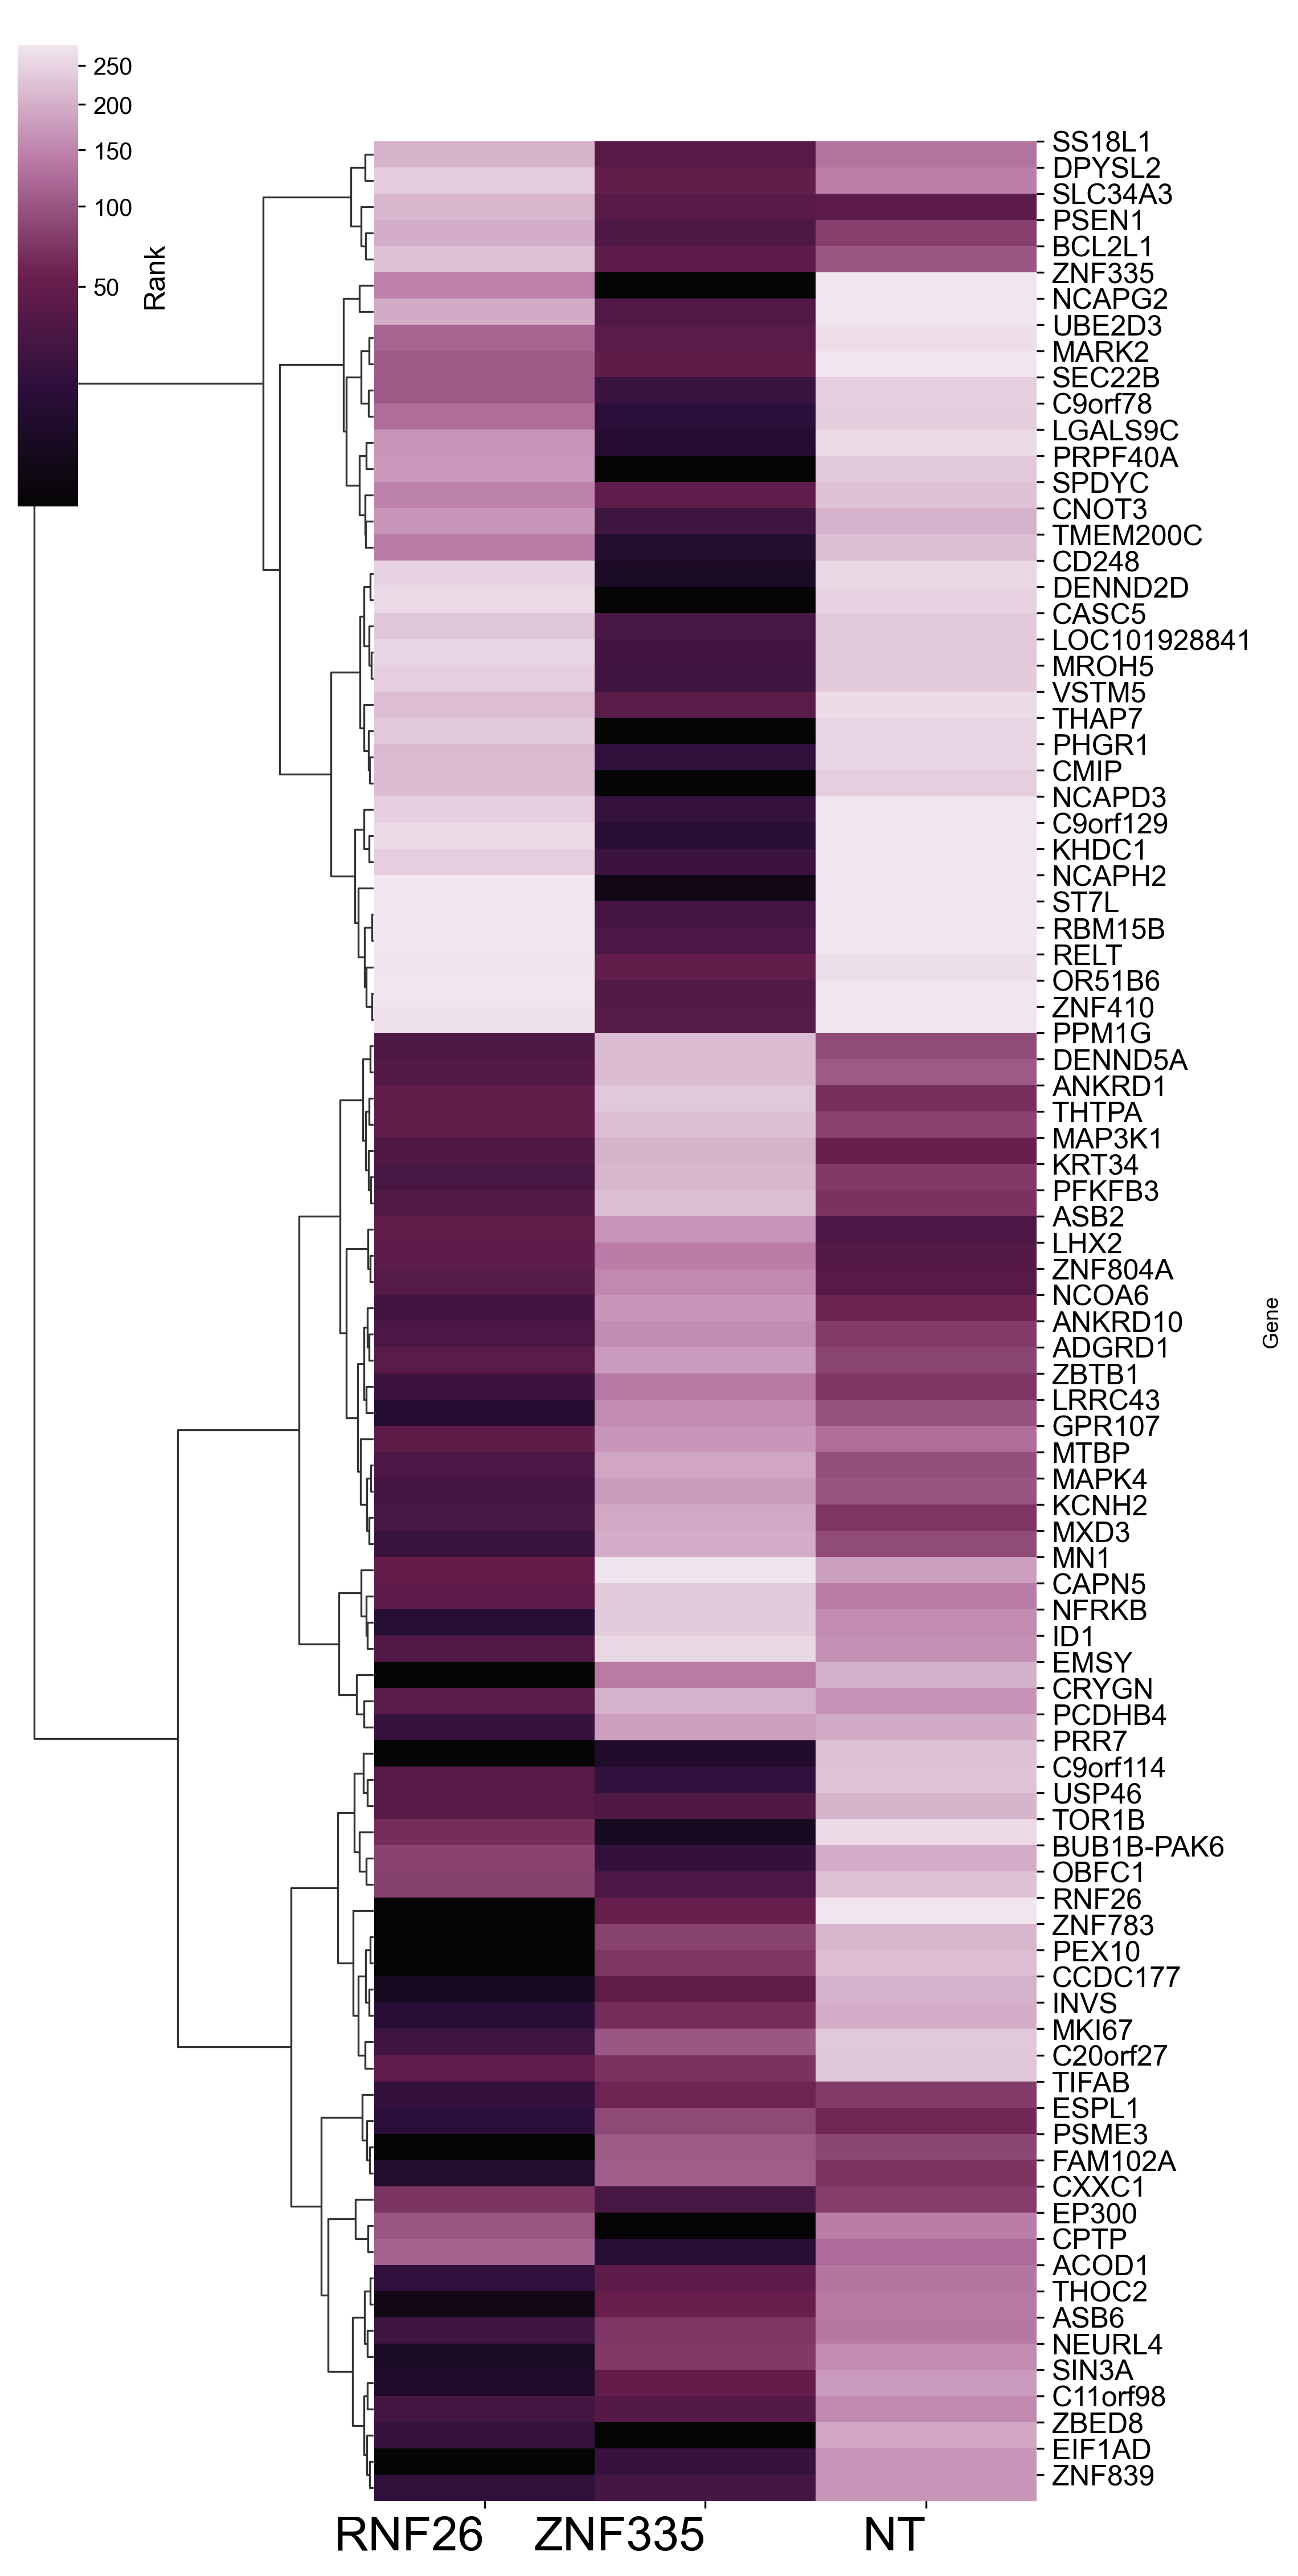

In [75]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, PowerNorm

# Load processed file
df = pd.read_excel("final_similarity_with_ranks.xlsx")

# Select top 50 by RNF26 and ZNF335
top_rnf = df.nsmallest(50, "sim_RNF26_rank")["Gene"]
top_znf = df.nsmallest(50, "sim_ZNF335_rank")["Gene"]
top_genes = pd.Index(top_rnf).union(pd.Index(top_znf))

# Subset and rename columns
rank_df = df[df["Gene"].isin(top_genes)].set_index("Gene")[[
    "sim_RNF26_rank", "sim_ZNF335_rank", "sim_B02_rank"
]]
rank_df.rename(columns={
    "sim_RNF26_rank": "RNF26",
    "sim_ZNF335_rank": "ZNF335",
    "sim_B02_rank": "NT"
}, inplace=True)

MAUVE_STRONG = [
    "#050505",  # near-black
    "#2b0f3a",  # deep eggplant
    "#6a1f4d",  # rich magenta
    "#b97aa6",  # soft mauve
    "#f1e6ee",  # very pale mauve-white
]
cmap = LinearSegmentedColormap.from_list("mauve_strong", MAUVE_STRONG, N=256)

# ---- Robust scaling so dark doesn't get lost ----
vals = rank_df.to_numpy().ravel()
vmin = np.percentile(vals, 5)
vmax = np.percentile(vals, 95)

# gamma < 1 expands contrast near the low end (dark side)
norm = PowerNorm(gamma=0.4, vmin=vmin, vmax=vmax)

import matplotlib as mpl

# Set global font to Arial
mpl.rcParams['font.family'] = 'Arial'

g = sns.clustermap(
    rank_df,
    cmap=cmap,
    norm = norm,
    metric="euclidean",
    method="ward",
    col_cluster=False,
    figsize=(7, 15),
    cbar_kws={"label": "Rank"},
    dendrogram_ratio=(0.35, 0.05),
    colors_ratio=0.01,
    tree_kws={"linewidths": 0.8}
)

# Row labels
g.ax_heatmap.set_yticks(range(len(rank_df)))
g.ax_heatmap.set_yticklabels(
    g.data2d.index,
    fontsize=12,
    rotation=0
)

# Column labels
g.ax_heatmap.set_xticklabels(
    g.data2d.columns,
    fontsize=20,
    ha="right"
)

# Colorbar font
g.cax.yaxis.label.set_size(12)
g.cax.tick_params(labelsize=10)
g.savefig("clustermap2.pdf", format="pdf", bbox_inches="tight")

# Or if you want to also see it interactively:
plt.show()

C:\Users\Schlieker Lab\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Schlieker Lab\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Schlieker Lab\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Schlieker Lab\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known

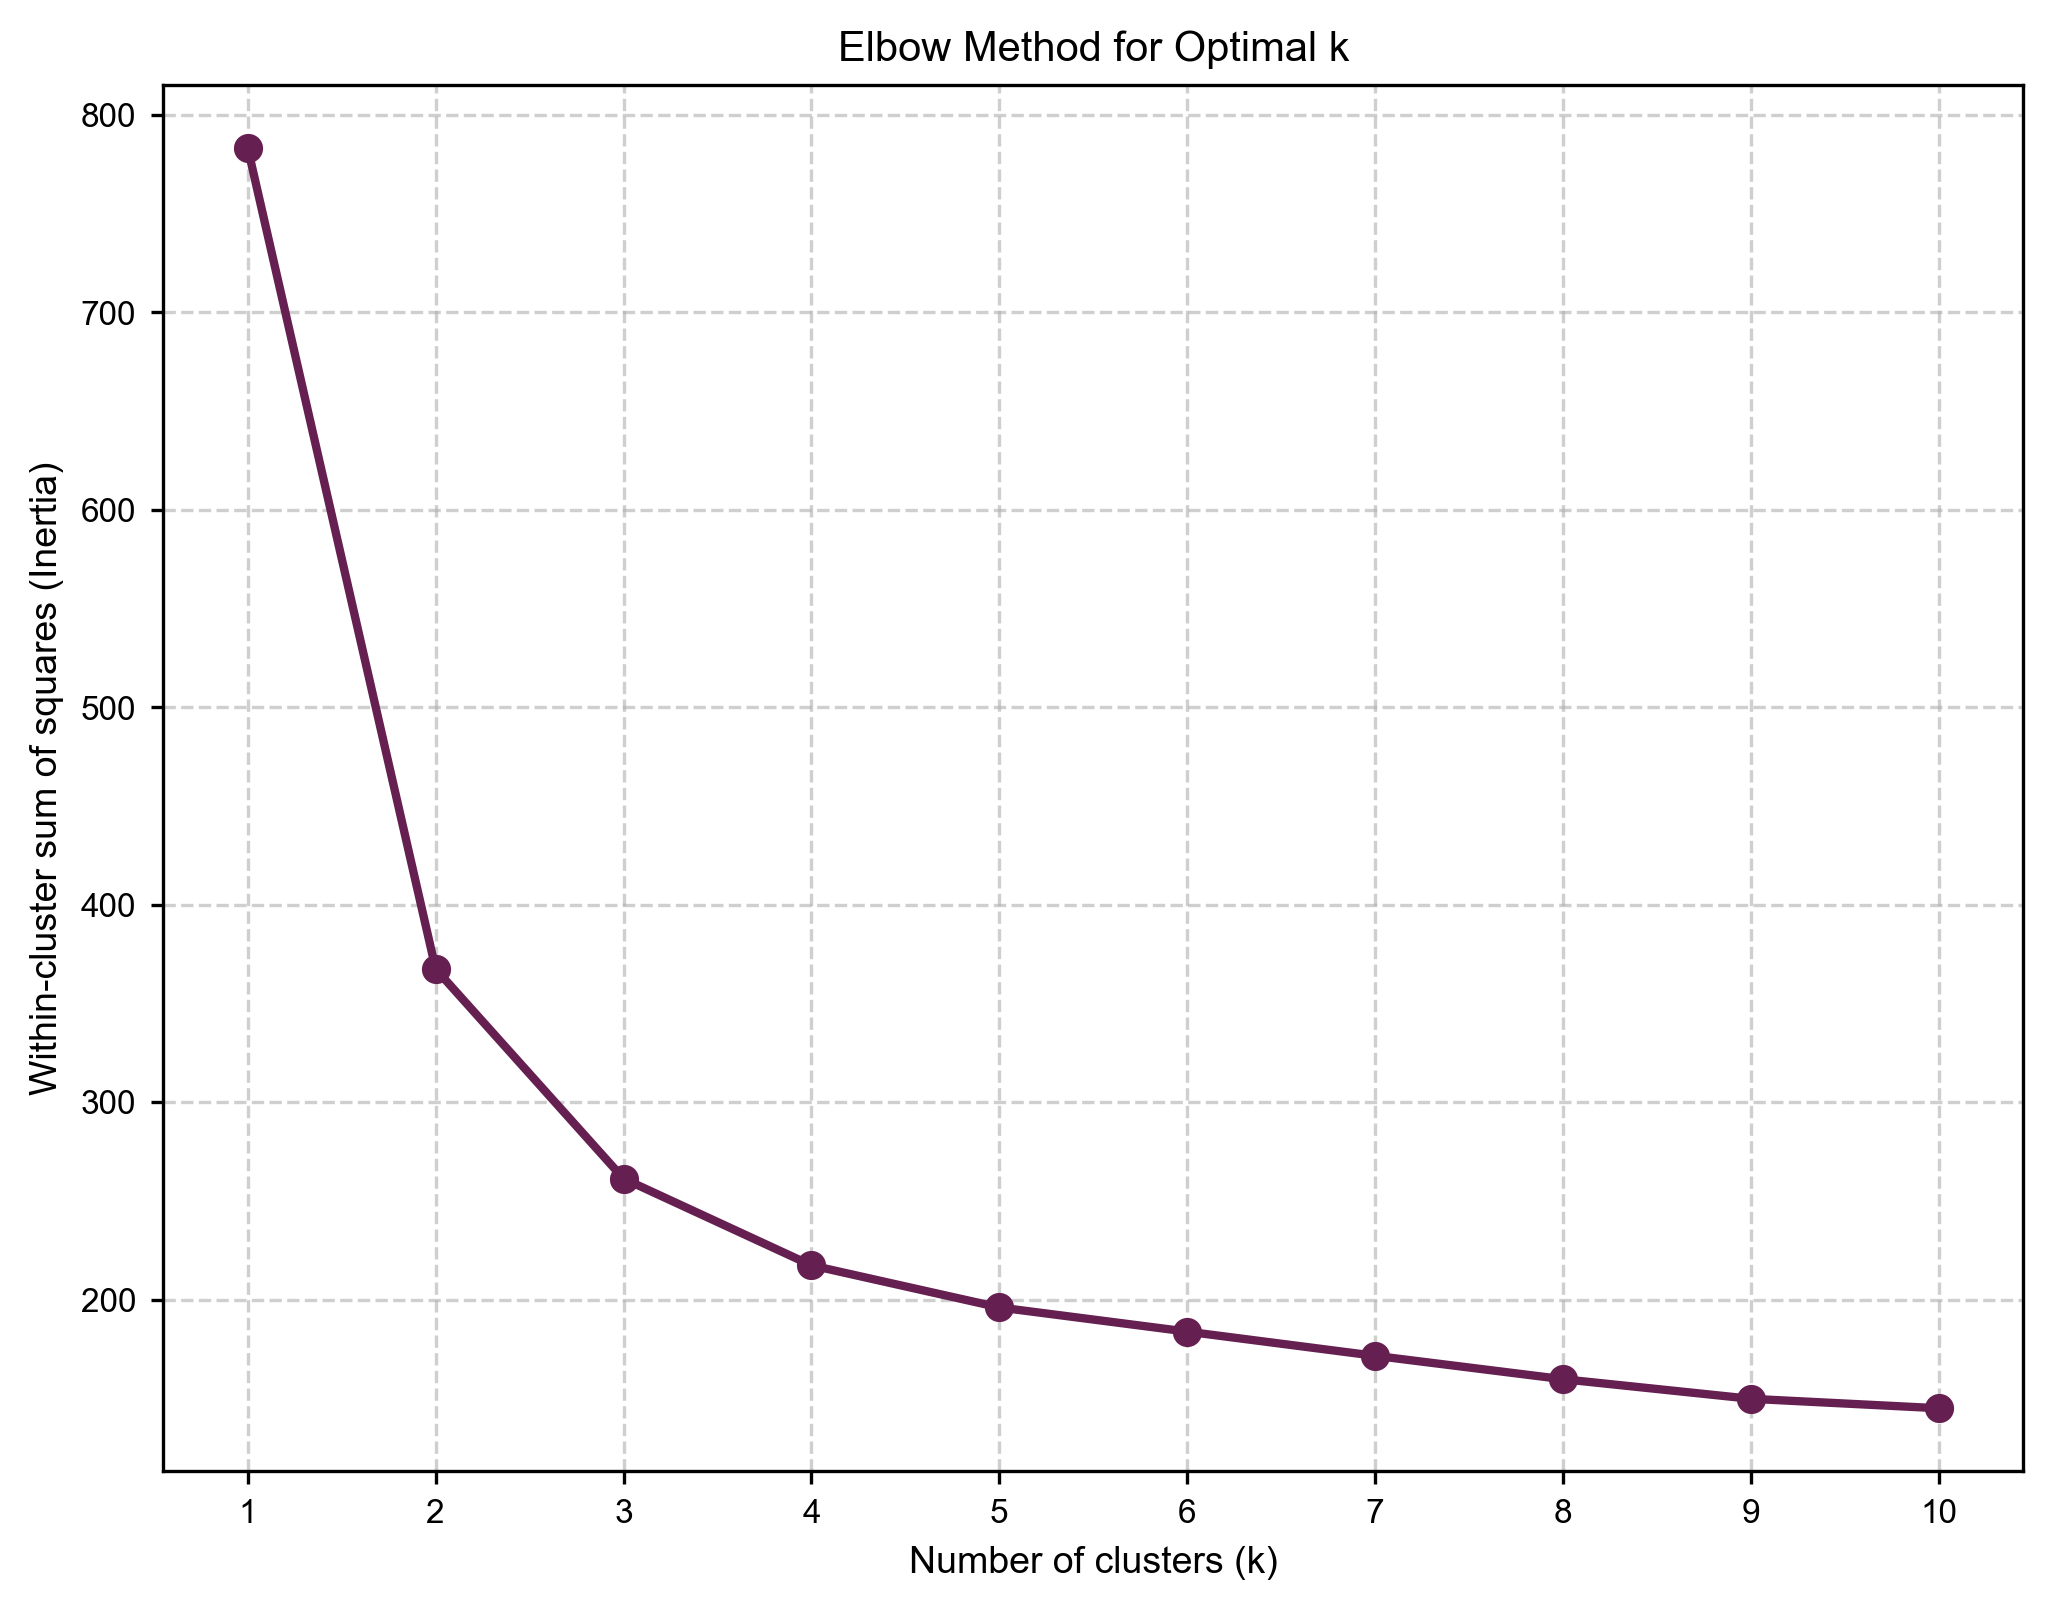

C:\Users\Schlieker Lab\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


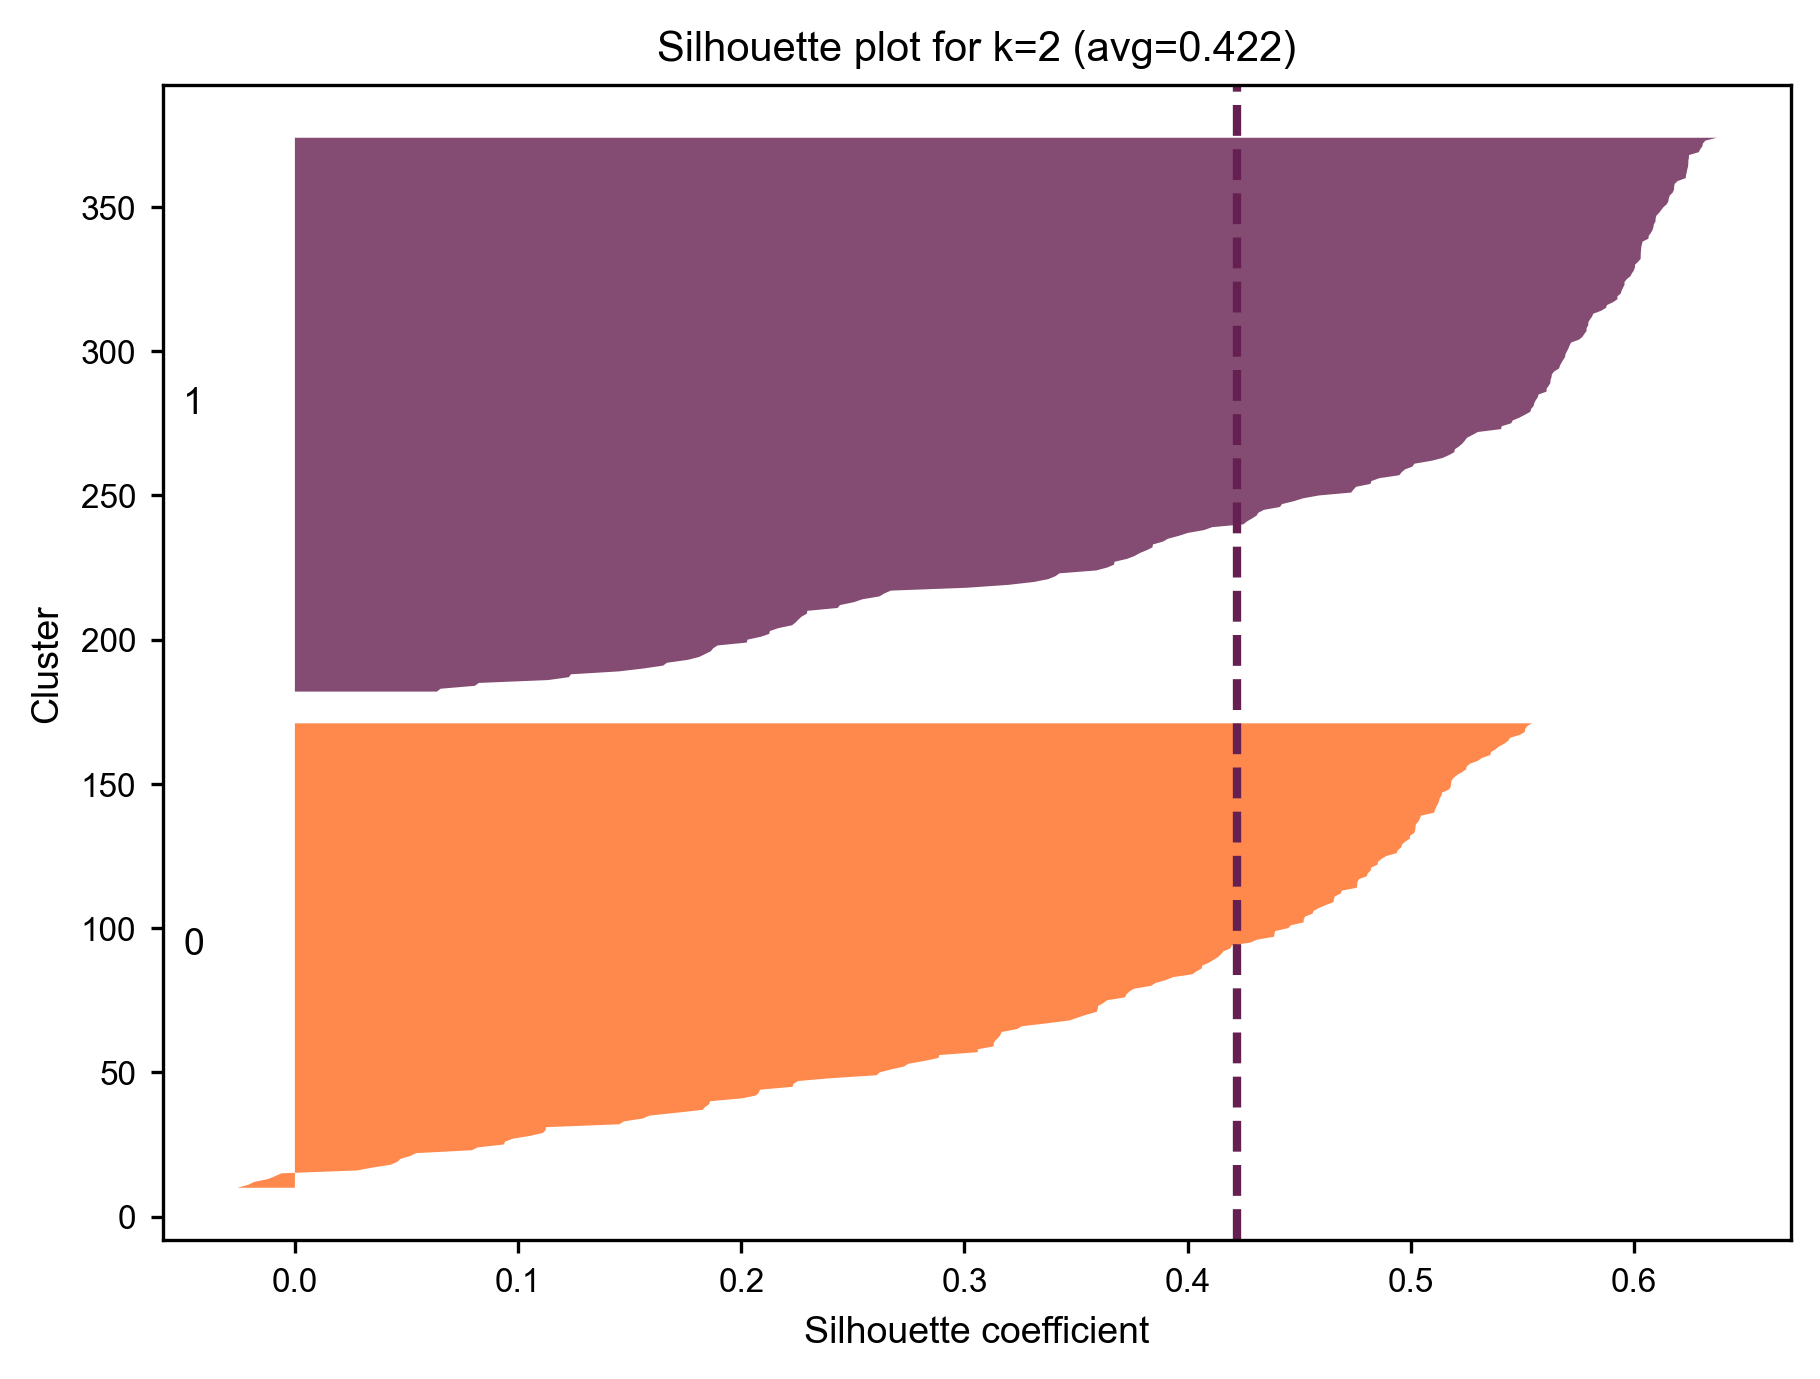

C:\Users\Schlieker Lab\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


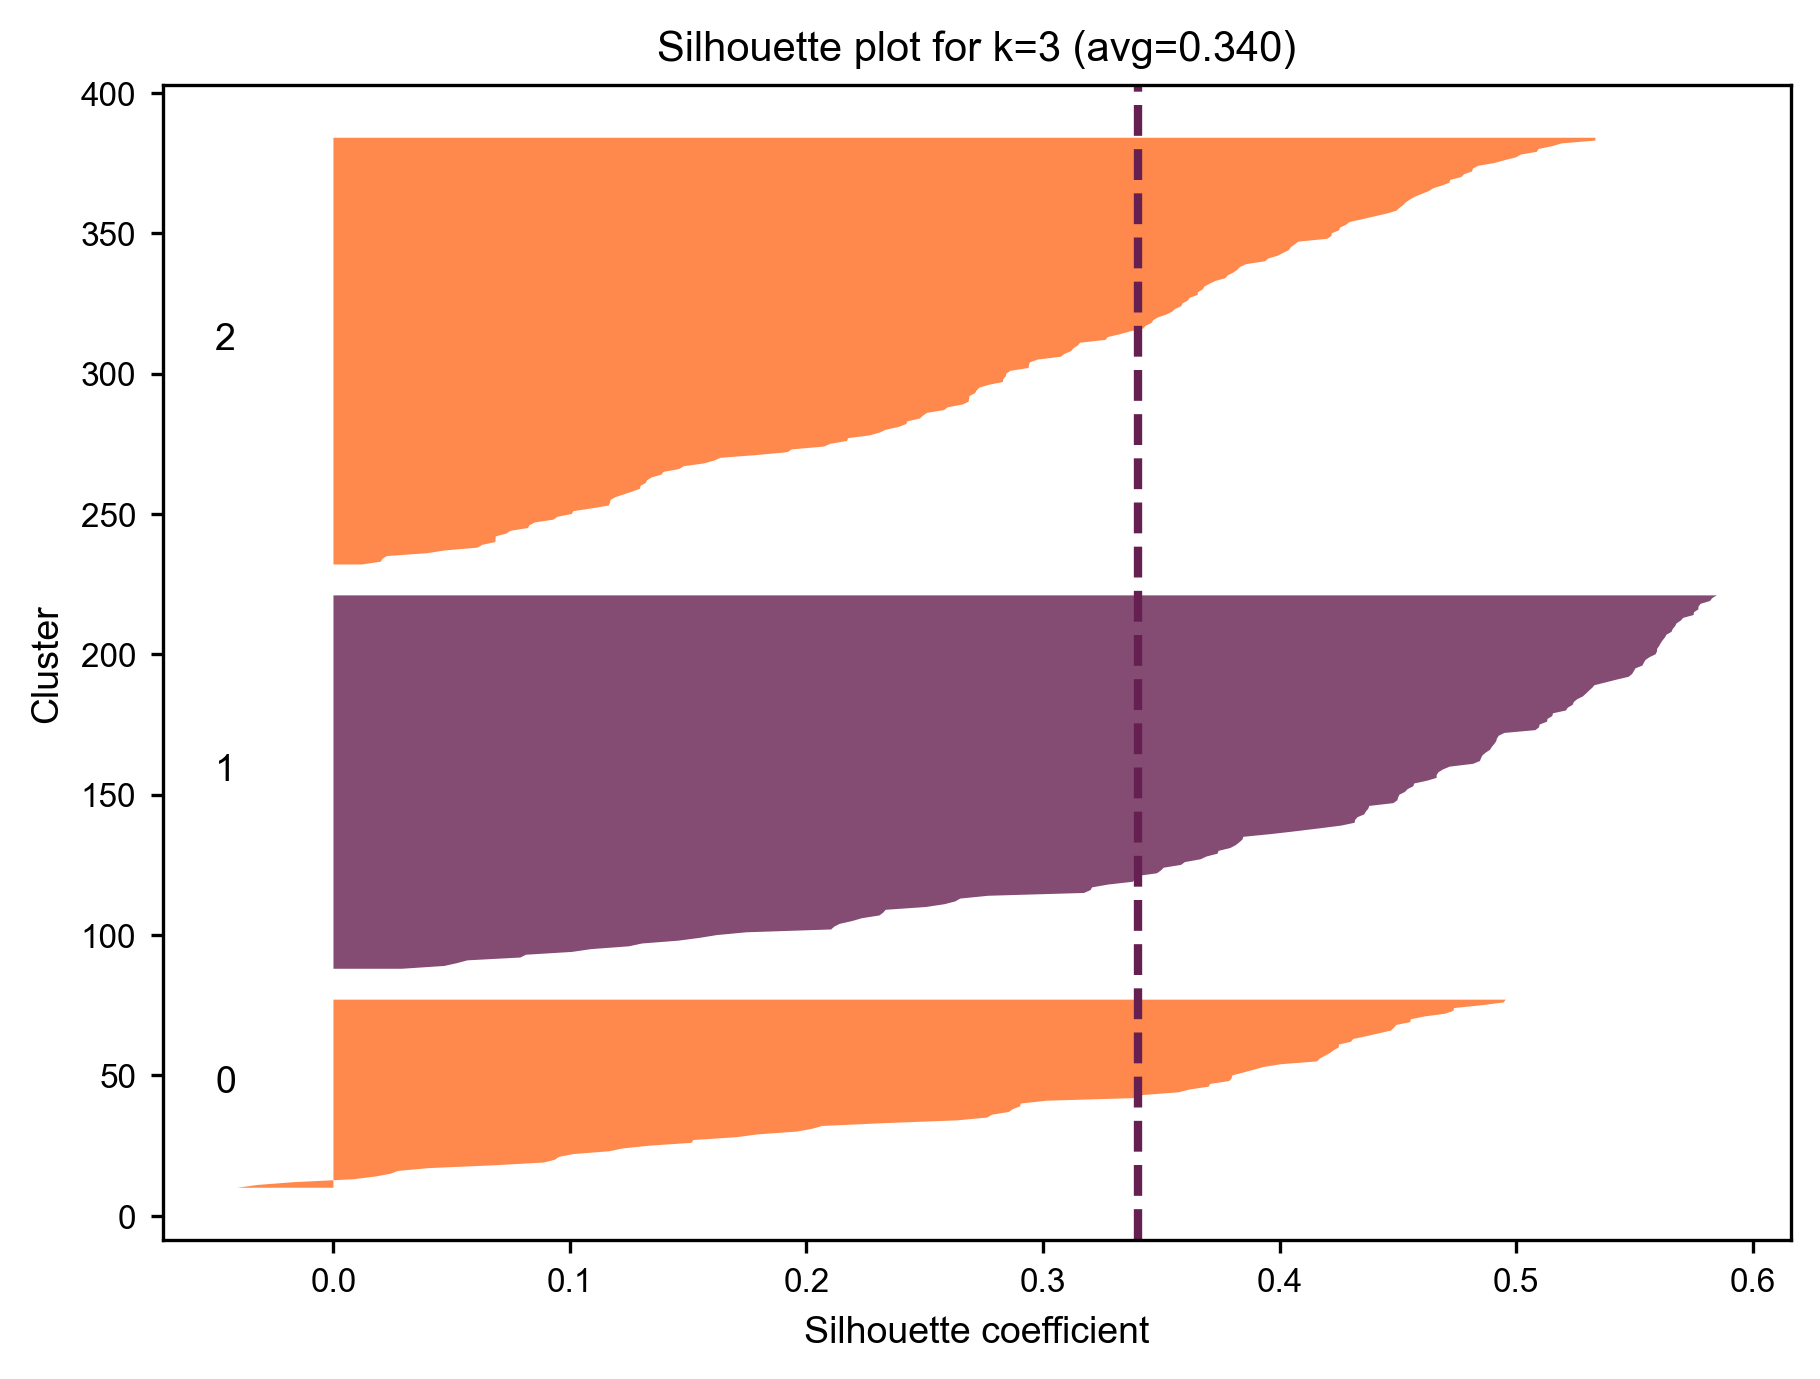

C:\Users\Schlieker Lab\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


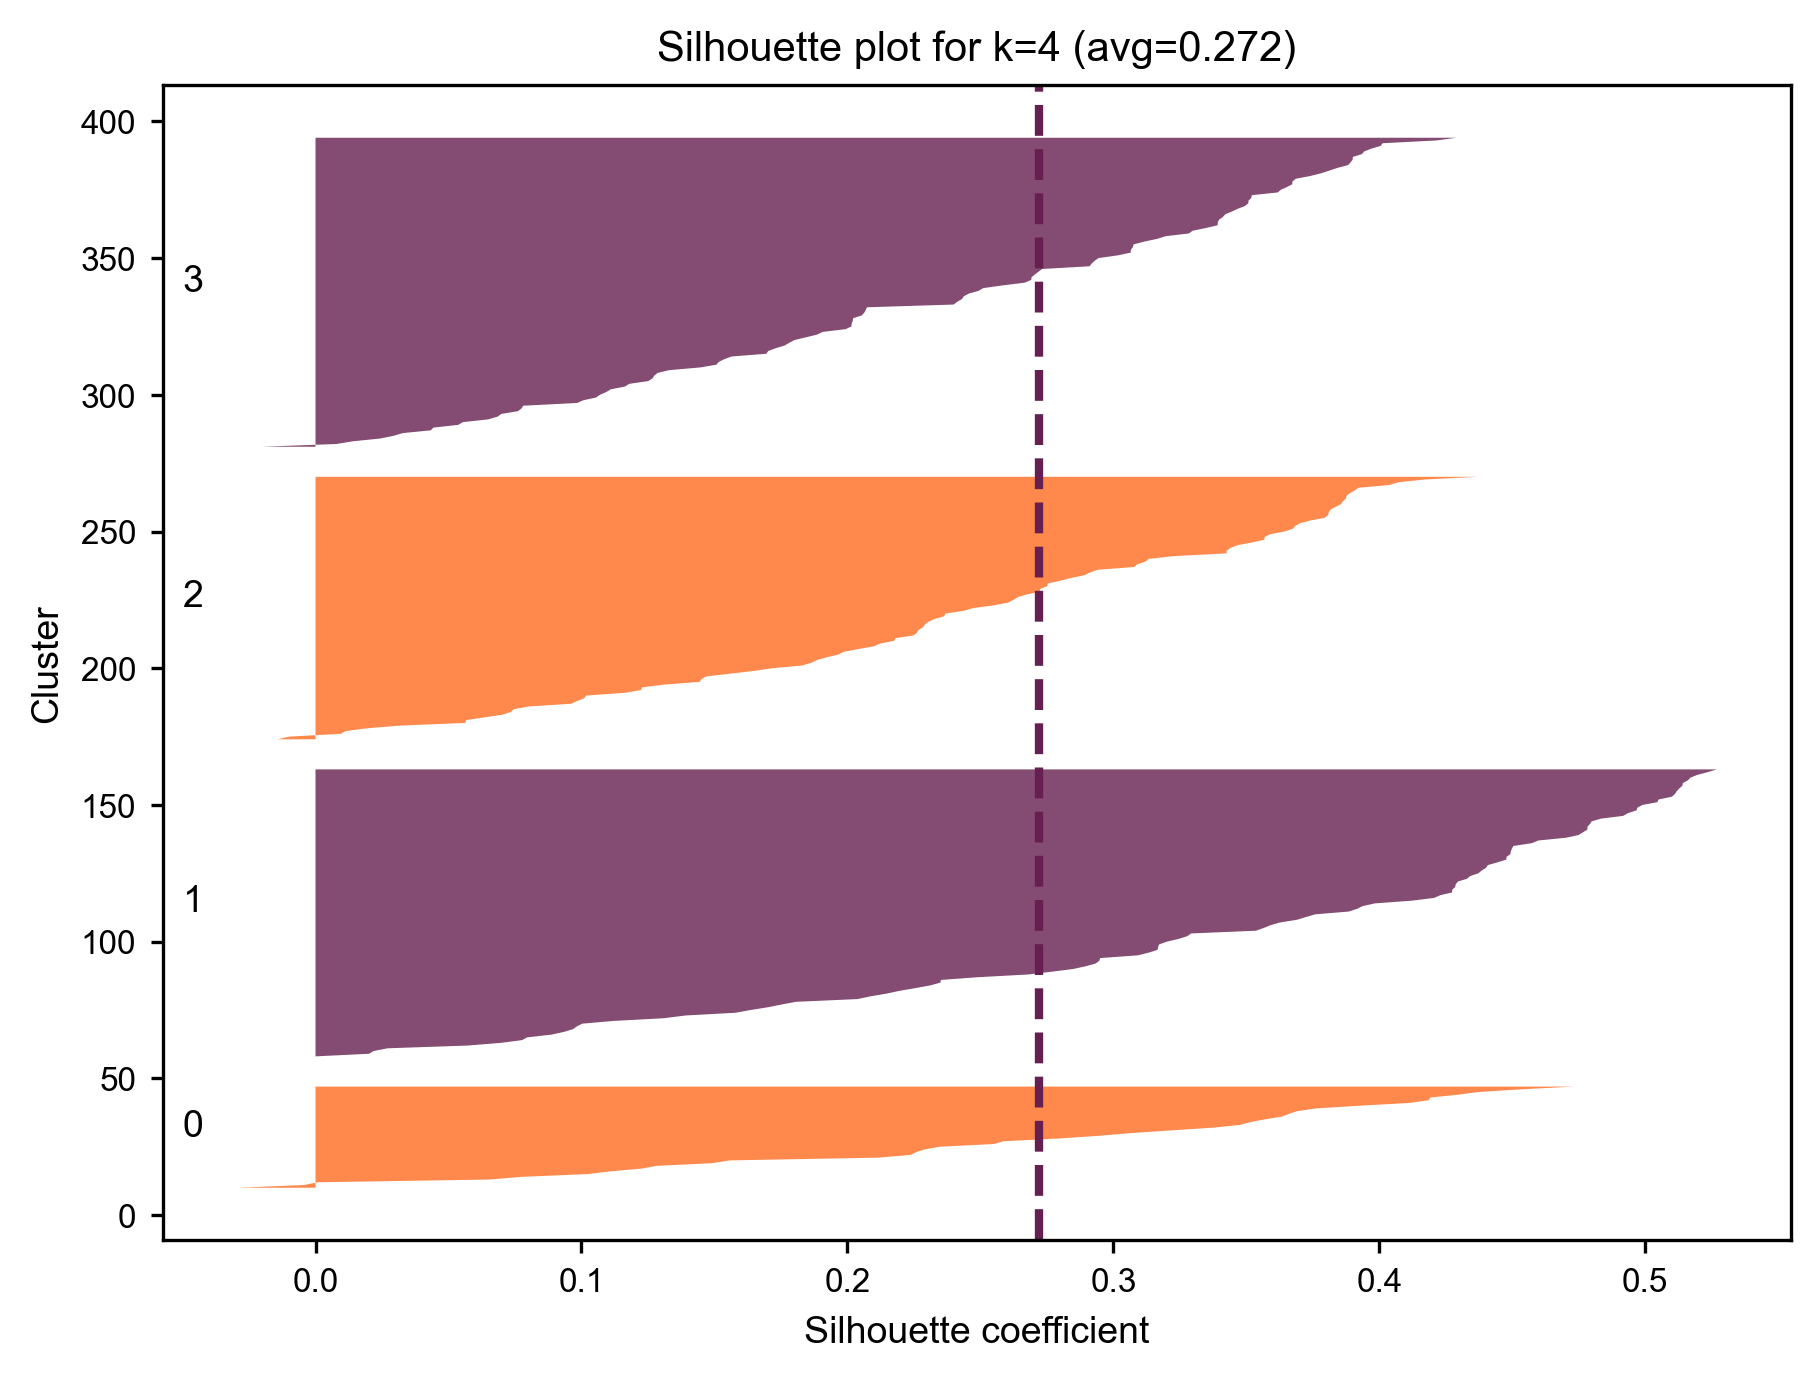

In [63]:
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.cluster import KMeans

# ---- Elbow Method ----
inertias = []
K = range(1, 11)   # test k = 1..10
for k in K:
    km = KMeans(n_clusters=k, random_state=42).fit(X)
    inertias.append(km.inertia_)

plt.figure(figsize=(8,6))
plt.plot(K, inertias, "o-", lw=2, color="#651f50")  # custom line color
plt.xlabel("Number of clusters (k)")
plt.ylabel("Within-cluster sum of squares (Inertia)")
plt.title("Elbow Method for Optimal k")
plt.xticks(K)
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

# ---- Detailed silhouette plots for chosen k ----
def silhouette_plot(X, k):
    fig, ax = plt.subplots(figsize=(7,5))
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    sil_vals = silhouette_samples(X, labels)
    sil_avg = silhouette_score(X, labels)

    y_lower = 10
    cluster_colors = ["#ff6c20", "#651f50"]  # custom cluster colors

    for i in range(k):
        ith_vals = sil_vals[labels == i]
        ith_vals.sort()
        size = len(ith_vals)
        y_upper = y_lower + size

        color = cluster_colors[i % len(cluster_colors)]  # cycle colors if k > 2
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_vals,
                         facecolor=color, alpha=0.8)
        ax.text(-0.05, y_lower + 0.5 * size, str(i))
        y_lower = y_upper + 10

    # custom silhouette avg line
    ax.axvline(x=sil_avg, color="#651f50", linestyle="--", lw=2)

    ax.set_title(f"Silhouette plot for k={k} (avg={sil_avg:.3f})")
    ax.set_xlabel("Silhouette coefficient")
    ax.set_ylabel("Cluster")
    plt.show()


# Example: show for k=2,3,4
silhouette_plot(X, 2)
silhouette_plot(X, 3)
silhouette_plot(X, 4)


In [71]:
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
from matplotlib.colors import LinearSegmentedColormap
from scipy.spatial import ConvexHull

# ----------------------------------
# 1. Elbow Plot
# ----------------------------------
with PdfPages("combined_panels.pdf") as pdf:
    plt.figure(figsize=(8,6))
    plt.plot(K, inertias, "o-", lw=2, color="#651f50")
    plt.xlabel("Number of clusters (k)")
    plt.ylabel("Within-cluster sum of squares (Inertia)")
    plt.title("Elbow Method for Optimal k")
    plt.xticks(K)
    plt.grid(True, linestyle="--", alpha=0.6)
    pdf.savefig()
    plt.close()

    # ----------------------------------
    # 2. Silhouette plot (k=3 only)
    # ----------------------------------
    fig, ax = plt.subplots(figsize=(7,5))
    kmeans = KMeans(n_clusters=3, random_state=42).fit(X)
    labels = kmeans.labels_
    sil_vals = silhouette_samples(X, labels)
    sil_avg = silhouette_score(X, labels)

    y_lower = 10
    cluster_colors = ["#ff6c20", "#e13c3d", "#651f50"]  # 3 cluster colors
    for i in range(3):
        ith_vals = sil_vals[labels == i]
        ith_vals.sort()
        size = len(ith_vals)
        y_upper = y_lower + size
        color = cluster_colors[i % len(cluster_colors)]
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_vals,
                         facecolor=color, alpha=0.8)
        ax.text(-0.05, y_lower + 0.5 * size, str(i))
        y_lower = y_upper + 10
    ax.axvline(x=sil_avg, color="#651f50", linestyle="--", lw=2)
    ax.set_title(f"Silhouette plot for k=3 (avg={sil_avg:.3f})")
    ax.set_xlabel("Silhouette coefficient")
    ax.set_ylabel("Cluster")
    pdf.savefig()
    plt.close()

  
 

C:\Users\Schlieker Lab\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
